# 114-2 社群媒體分析 3rd 讀書會專案
組別：Group 1  
組員：  
```
M144020007 詹襄秝 、M144020020 林芷庭 、M144020021 劉淨涵 、M144020030 賴昱霖  
M134020047 廖經恆 、M144020052 張恩誠 、M144020056 張祐豪 、M144020068 陳啓恩  
```
動機：
```
本專案旨在結合「新青安」與「擴大租屋補助」兩大核心政策，透過大數據輿情分析探討PTT社群對雙軌居住政策的真實態度。
藉由對比「理性新聞報導」的體制特徵與「感性網民評論」中的居住焦慮與租金轉嫁剝奪感，深入洞察青年族群在當前房市金融衝擊下的生存現況。
```

# 第十一週：Text Embeddings
資料集介紹:
```
時間: 2025/01/01 ~ 2026/04/30
來源: PTT 房屋版
關鍵字: 新青安
資料筆數: 740
```
動機：
```
新青年政策是近年來台灣房地產市場中最具影響力、且與青年族群財務命運最直接掛鉤的核心政策變因。自 2023 年推出以來，該政策不僅透過利息補貼與貸款
年限的拉長，實質改變了購屋門檻，更進一步引發了關於房價推升、信用擴張及世代公平性的激烈爭議。站在 2026 年政策即將由 1.0 轉型至 2.0 的歷史
節點，首批使用者的寬限期屆滿壓力，正與新一輪的查核機制相互交織，因此透過分析該主題觀察台灣房市金融韌性與青年居住焦慮變遷。
```

### 套件載入

In [ ]:
import pandas as pd
import jieba
import jieba.analyse
import re
import numpy as np
from collections import defaultdict
import multiprocessing

from gensim.models.phrases import Phrases, Phraser
from gensim.models import Word2Vec, KeyedVectors

from gensim.models import Word2Vec

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import seaborn as sns
import torch

from matplotlib.font_manager import fontManager
import plotly.express as px

sns.set_style("darkgrid")

c:\Users\orika\anaconda3\envs\sma2026\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### 資料前處理

In [ ]:
# 設定繁體中文詞庫
jieba.set_dictionary('./dict/dict.txt.big')
jieba.load_userdict('./dict/user_dict.txt')

# 新增stopwords
with open('./dict/stopwords.txt',encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

Building prefix dict from c:\Users\nini\Desktop\NSYSU\1142\MIS581\3rd_project\dict\dict.txt.big ...
Loading model from cache C:\Users\nini\AppData\Local\Temp\jieba.u859e17fada38729db6ed4932523aece7.cache
Loading model cost 1.809 seconds.
Prefix dict has been built successfully.


In [ ]:
# 斷詞函式
def getToken(row):
    seg_list = jieba.lcut(row)
    seg_list = [w for w in seg_list if w not in stopWords and len(w)>1] # 篩選掉停用字與字元數小於1的詞彙

    return seg_list

In [ ]:
# 讀入中文示範資料集
origin_data = pd.read_csv('home_sale.csv')

In [ ]:
# 資料前處理

# 去除一些不需要的欄位
metaData = origin_data.drop(['artPoster', 'artCatagory', 'artComment', 'e_ip', 'insertedDate', 'dataSource'], axis=1)

# 只留下中文字
metaData['sentence'] = metaData['artContent'].str.replace(r'\n\n','。', regex=True)
metaData['sentence'] = metaData['sentence'].str.replace(r'\n','', regex=True)

metaData['sentence'] = metaData['sentence'].str.split("[,，。！!？?]{1,}")
metaData = metaData.explode('sentence').reset_index(drop=True)

metaData['sentence'] = metaData['sentence'].apply(lambda x: re.sub('[^\u4e00-\u9fff]+', '',x))

metaData['word'] = metaData.sentence.apply(getToken)

metaData = metaData[metaData['word'].apply(len) > 0]

metaData.head(10)

,system_id,artUrl,artTitle,artDate,artContent,sentence,word
0,1,https://www.ptt.cc/bbs/home-sale/M.1735694794....,[閒聊]中古屋都是誰在買？,2025-01-01 09:26:32,年輕人愛好新房子\n\n買預售屋還款壓力小\n\n配合新青安很容易就能成家立業\n\n可以客...,年輕人愛好新房子,"[年輕人, 愛好, 新房子]"
1,1,https://www.ptt.cc/bbs/home-sale/M.1735694794....,[閒聊]中古屋都是誰在買？,2025-01-01 09:26:32,年輕人愛好新房子\n\n買預售屋還款壓力小\n\n配合新青安很容易就能成家立業\n\n可以客...,買預售屋還款壓力小,"[預售, 還款, 壓力]"
2,1,https://www.ptt.cc/bbs/home-sale/M.1735694794....,[閒聊]中古屋都是誰在買？,2025-01-01 09:26:32,年輕人愛好新房子\n\n買預售屋還款壓力小\n\n配合新青安很容易就能成家立業\n\n可以客...,配合新青安很容易就能成家立業,"[配合, 新青安, 成家立業]"
3,1,https://www.ptt.cc/bbs/home-sale/M.1735694794....,[閒聊]中古屋都是誰在買？,2025-01-01 09:26:32,年輕人愛好新房子\n\n買預售屋還款壓力小\n\n配合新青安很容易就能成家立業\n\n可以客...,可以客變,[客變]
4,1,https://www.ptt.cc/bbs/home-sale/M.1735694794....,[閒聊]中古屋都是誰在買？,2025-01-01 09:26:32,年輕人愛好新房子\n\n買預售屋還款壓力小\n\n配合新青安很容易就能成家立業\n\n可以客...,不用擔心管線老舊,"[擔心, 管線, 老舊]"
5,1,https://www.ptt.cc/bbs/home-sale/M.1735694794....,[閒聊]中古屋都是誰在買？,2025-01-01 09:26:32,年輕人愛好新房子\n\n買預售屋還款壓力小\n\n配合新青安很容易就能成家立業\n\n可以客...,好奇中古屋都是誰在買,"[好奇, 古屋]"
6,2,https://www.ptt.cc/bbs/home-sale/M.1735798314....,[請益]房貸方案請益,2025-01-02 14:11:52,各位前輩好，最近準備要辦理房貸，目前評估以下兩個方案，想請教大家的建議。\n貸款人是先生，太...,各位前輩好,[前輩]
7,2,https://www.ptt.cc/bbs/home-sale/M.1735798314....,[請益]房貸方案請益,2025-01-02 14:11:52,各位前輩好，最近準備要辦理房貸，目前評估以下兩個方案，想請教大家的建議。\n貸款人是先生，太...,最近準備要辦理房貸,"[辦理, 房貸]"
8,2,https://www.ptt.cc/bbs/home-sale/M.1735798314....,[請益]房貸方案請益,2025-01-02 14:11:52,各位前輩好，最近準備要辦理房貸，目前評估以下兩個方案，想請教大家的建議。\n貸款人是先生，太...,目前評估以下兩個方案,"[評估, 兩個, 方案]"
9,2,https://www.ptt.cc/bbs/home-sale/M.1735798314....,[請益]房貸方案請益,2025-01-02 14:11:52,各位前輩好，最近準備要辦理房貸，目前評估以下兩個方案，想請教大家的建議。\n貸款人是先生，太...,想請教大家的建議,"[請教, 建議]"


### Word2Vec

In [ ]:
sents = metaData['word'].to_list()
bigrams = Phrases(sents,min_count=1, threshold=1000)
bigram_phrasers = Phraser(bigrams)
metaData['word_list_bigrams'] = list(bigram_phrasers[sents])

metaData.head()

,system_id,artUrl,artTitle,artDate,artContent,sentence,word,word_list_bigrams
0,1,https://www.ptt.cc/bbs/home-sale/M.1735694794....,[閒聊]中古屋都是誰在買？,2025-01-01 09:26:32,年輕人愛好新房子\n\n買預售屋還款壓力小\n\n配合新青安很容易就能成家立業\n\n可以客...,年輕人愛好新房子,"[年輕人, 愛好, 新房子]","[年輕人, 愛好, 新房子]"
1,1,https://www.ptt.cc/bbs/home-sale/M.1735694794....,[閒聊]中古屋都是誰在買？,2025-01-01 09:26:32,年輕人愛好新房子\n\n買預售屋還款壓力小\n\n配合新青安很容易就能成家立業\n\n可以客...,買預售屋還款壓力小,"[預售, 還款, 壓力]","[預售, 還款, 壓力]"
2,1,https://www.ptt.cc/bbs/home-sale/M.1735694794....,[閒聊]中古屋都是誰在買？,2025-01-01 09:26:32,年輕人愛好新房子\n\n買預售屋還款壓力小\n\n配合新青安很容易就能成家立業\n\n可以客...,配合新青安很容易就能成家立業,"[配合, 新青安, 成家立業]","[配合, 新青安, 成家立業]"
3,1,https://www.ptt.cc/bbs/home-sale/M.1735694794....,[閒聊]中古屋都是誰在買？,2025-01-01 09:26:32,年輕人愛好新房子\n\n買預售屋還款壓力小\n\n配合新青安很容易就能成家立業\n\n可以客...,可以客變,[客變],[客變]
4,1,https://www.ptt.cc/bbs/home-sale/M.1735694794....,[閒聊]中古屋都是誰在買？,2025-01-01 09:26:32,年輕人愛好新房子\n\n買預售屋還款壓力小\n\n配合新青安很容易就能成家立業\n\n可以客...,不用擔心管線老舊,"[擔心, 管線, 老舊]","[擔心, 管線, 老舊]"


In [ ]:
word_freq = defaultdict(int)
# 計算詞頻
sents = metaData['word_list_bigrams'].tolist()
for sent in sents: # sent 中的每個句子
    for i in sent: # i 是句子中的每個字
        word_freq[i] += 1

In [ ]:
print(f"total unique words in sentences: {len(word_freq)}")
sorted(word_freq, key=word_freq.get, reverse=True)[:10]

total unique words in sentences: 19265


['新青安', '銀行', '房貸', '貸款', '房價', '房市', '央行', '政策', '市場', '預售']

從高頻詞可以發現，除了「新青安」本身外，討論幾乎被「銀行」、「房貸」、「貸款」、「央行」等詞彙主導。
這代表在 2025–2026 年期間，PTT 房屋版對新青安的關注核心，已從「買哪裡的房子」逐漸轉向「能不能貸得到款」。
討論反映出首購族對貸款條件、銀行核貸與政策變化的高度敏感，也顯示新青安政策與整體房市、資金環境之間存在明顯連動。

In [ ]:
print(f"sentence number of corpus: {len(sents)}")
i = 0
for sent in sents:
    i = i + len(sent)
print(f"average length of sentences: {i/len(sents)}")

sentence number of corpus: 28154
average length of sentences: 3.76024721176387


Word2Vec 計算

In [ ]:
# 環境變數設定
%env PYTHONHASHSEED=2025

env: PYTHONHASHSEED=2025


In [ ]:
# 查看機器的core
cores = multiprocessing.cpu_count()
print(f"number of cores: {cores}")

number of cores: 8


In [ ]:
# 建立模型
w2v_model = Word2Vec(sents,
                     min_count=30,# 小於30次tf的字會被刪除
                     window=2,# 往左右各2的距離
                     vector_size=128,# vector 的維度
                     sample=0.005,# 愈小的話，高tf的字會不容易被選到
                     alpha=0.001,# learning rate
                     min_alpha=0.0005, # 迭代到最小的learning rate，learning rate會慢慢下降至min_alpha
                     negative=0,
                     workers=cores-1, # 用的cpu資源
                     seed=8787,
                     sg = 1,# 0/1 是否使用skip gram
                     epochs= 30,
                     hs=1 , # hierarchical softmax
                     )

查看結果

In [ ]:
# 檢查最相關的字
w2v_model.wv.most_similar('新青安',topn=10)

[('利率', 0.7361103296279907),
 ('方案', 0.6674733757972717),
 ('寬限期', 0.6452464461326599),
 ('五年', 0.629740297794342),
 ('首購', 0.6219334006309509),
 ('壓力', 0.6081845760345459),
 ('利息', 0.6071082949638367),
 ('購屋', 0.5892766714096069),
 ('青安貸款', 0.5875199437141418),
 ('貸款', 0.5744109749794006)]

與「新青安」最相關的詞集中在「利率」、「寬限期」、「首購」與「貸款」等房貸條件，顯示討論焦點主要圍繞在購屋資金壓力與貸款優惠。
這反映出新青安在使用者認知中，已高度連結到「降低首購負擔」的政策功能。

In [ ]:
w2v_model.wv.most_similar('貸款',topn=10)

[('房貸', 0.7275519371032715),
 ('降低', 0.6328971982002258),
 ('民眾', 0.627556562423706),
 ('寬限期', 0.6115189790725708),
 ('青安貸款', 0.6046766042709351),
 ('金額', 0.589739203453064),
 ('辦理', 0.5855920314788818),
 ('新青安', 0.5744109749794006),
 ('符合', 0.5688194632530212),
 ('萬年', 0.5616392493247986)]

從「貸款」的語意相似詞可發現，其高度關聯於「房貸」、「寬限期」、「青安貸款」與「金額」等詞，顯示貸款議題主要聚焦在房貸條件、申請資格與還款壓力。
同時「新青安」也出現在相關詞中，代表兩者在討論脈絡上具有高度連結。

In [ ]:
w2v_model.wv.most_similar(['新青安','貸款'],topn=10)

[('利率', 0.7308050990104675),
 ('寬限期', 0.7082394957542419),
 ('方案', 0.6796438097953796),
 ('青安貸款', 0.6718522906303406),
 ('民眾', 0.666854977607727),
 ('房貸', 0.6629705429077148),
 ('金額', 0.632348358631134),
 ('辦理', 0.6270360946655273),
 ('寬限', 0.624705970287323),
 ('優惠', 0.6187595129013062)]

從「新青安」與「貸款」的共同語意分析發現，最相關的詞集中在「利率」、「寬限期」、「房貸」與「優惠」等貸款條件，顯示討論主要圍繞在購屋貸款優惠與還款壓力。
這也反映出新青安政策在使用者認知中，與房貸優惠措施具有高度連結。


In [ ]:
# 跟兩個字最不相關
w2v_model.wv.most_similar(negative=['新青安','貸款'],topn=10)

[('讓利', 0.5399836897850037),
 ('新聞', 0.5160472989082336),
 ('分享', 0.5027168989181519),
 ('房市', 0.5017554759979248),
 ('經濟', 0.4976137578487396),
 ('崩盤', 0.49669820070266724),
 ('保守', 0.493491530418396),
 ('產業', 0.47428539395332336),
 ('房屋', 0.46459436416625977),
 ('台灣', 0.44920873641967773)]

在排除「新青安」與「貸款」的語境後，最不相關的詞集中於「新聞」、「經濟」、「崩盤」、「產業」等較宏觀的市場與總體經濟詞彙，顯示該模型主要將討論核心鎖定在房貸與政策細節層面，而非總體經濟敘事。


In [ ]:
# 計算兩個字之間的關係
w2v_model.wv.similarity("首購","利率")

0.82937956

In [ ]:
w2v_model.wv.similarity("年限","寬限期")

0.64536595

In [ ]:
# 比較字詞間，誰最不相關（邊緣）
w2v_model.wv.doesnt_match(["年限", "寬限期", "貸款", "利率", "補貼"])

'貸款'

In [ ]:
# 相對關係
w2v_model.wv.most_similar(positive=["首購"], negative=["利率"], topn=5)

[('投資', 0.6751886010169983),
 ('管制', 0.6432607173919678),
 ('資源', 0.5922726988792419),
 ('控管', 0.5840288400650024),
 ('放款', 0.5810567140579224)]

在排除「利率」影響後，「首購」的語意更偏向「投資」、「管制」、「控管」與「放款」等政策與市場調控相關詞彙，顯示討論焦點從個人房貸條件轉向更宏觀的房市資源配置與金融管制議題。


In [ ]:
# 取得所有的字
words = w2v_model.wv.key_to_index.keys()

視覺化字之間的關係及將字做分群

In [ ]:
# 降維：利用PCA tSNE

def reduceDim(mat,method:str='PCA',dim:str=2,perplexity = 25,learning_rate = 400):

    method_dict = {
        "PCA":PCA(n_components=dim,iterated_power = 1000,random_state=0),
        "TSNE":TSNE(n_components=dim,random_state=0,perplexity=perplexity,learning_rate=learning_rate),
    }
    new_feat = method_dict[method].fit_transform(mat)

    return new_feat


In [ ]:
# 拿到list of words 的vector
def getVecs(model,words:list):
    vecs = []
    for i in words:
        vecs.append(model.wv[i])
    return np.vstack(vecs)


In [ ]:
getVecs(w2v_model,['青安貸款','首購族'])

array([[ 0.00854783,  0.03472426, -0.0112039 ,  0.0436104 , -0.00623049,
        -0.03262305,  0.01005032, -0.03774639,  0.02132681, -0.01114408,
         0.00690474,  0.01537389, -0.00603831, -0.01063822,  0.01725287,
         0.03409091,  0.00950101,  0.00541595, -0.00114517,  0.02962421,
        -0.0025266 ,  0.00226627,  0.01101886, -0.00789255, -0.01366989,
         0.03913532,  0.00084954,  0.01252403, -0.00699702, -0.0257252 ,
         0.03636526,  0.00720269, -0.00526083,  0.02344878,  0.01758364,
        -0.03853466,  0.00697405, -0.03455846, -0.0165941 , -0.00671054,
         0.03261637, -0.01148634,  0.00129527, -0.00662524, -0.00441226,
        -0.02431342,  0.00181566,  0.02592883, -0.0125007 , -0.01630376,
         0.02492985, -0.0145674 , -0.0435643 ,  0.00918697,  0.00218298,
        -0.01015547, -0.00673471, -0.01011965,  0.00021559, -0.02351863,
        -0.00976208,  0.00153886,  0.0287129 ,  0.00992495,  0.02159725,
        -0.01255856, -0.00014399,  0.00597057, -0.0

In [ ]:
# 擴展相似的字詞
def expandPosWord(model, words:list, top_n:int, split = True):

    if split == False:
        wp = model.wv.most_similar(words,topn = top_n)
        return wp
    expand = []

    for w in words:
        wp = model.wv.most_similar(w,topn = top_n)
        for i in wp:
            expand.append(i[0])

    return list(set(expand))


In [ ]:
expandPosWord(w2v_model,['青安貸款','寬限期'],top_n = 10)

['標準',
 '寬限',
 '三年',
 '協助',
 '青安貸款',
 '額度',
 '五年',
 '申請',
 '補助',
 '利率',
 '提高',
 '延長',
 '貸款額度',
 '符合',
 '賣方',
 '取消',
 '補貼',
 '年限',
 '本金']

擴展「青安貸款」與「寬限期」相關詞後，可發現語意主要集中於利率、額度、年限與補貼等貸款條件，以及申請與資格流程，顯示討論核心圍繞在房貸政策細節與還款設計。
PTT 討論「新青安」是在討論貸得到多少、寬限期幾年、利率多少。

In [ ]:
# 畫出兩維的散佈圖
def plotScatter(vec_df):
    """
    vec_df: 字詞及其兩個維度的值
    """
    plt.figure(figsize=(15,15))
    fontManager.addfont('./TaipeiSansTCBeta-Regular.ttf')
    plt.rcParams['font.sans-serif'] = ['Taipei Sans TC Beta']
    plt.rcParams['font.size'] = '16'

    p = sns.scatterplot(x="dim1", y="dim2",
                  data=vec_df)
    for line in range(0, vec_df.shape[0]):
         p.text(vec_df["dim1"][line],
                 vec_df['dim2'][line],
                 '  ' + vec_df["word"][line].title(),
                 horizontalalignment='left',
                 verticalalignment='bottom', size='medium',
                 weight='normal'
                ).set_size(15)
    plt.show()

# 畫出三維的散佈圖
def plotScatter3D(vec_df):
    vec_df['size'] = .5
    if 'color' not in vec_df.columns:
        vec_df['color'] = 'blue'
    fig = px.scatter_3d(
        vec_df,'dim1','dim2','dim3',text = 'word',width=800, height=800,color = 'color',size = 'size'

    )

    fig.show()

In [ ]:
sample_words = np.random.choice(list(words),300,replace=False).tolist()

feat = getVecs(model=w2v_model,words=sample_words)
print(feat.shape)
new_feat = reduceDim(feat,method='TSNE',perplexity=20,learning_rate = 800)
print(new_feat.shape)

(300, 128)
(300, 2)


In [ ]:
word_df = pd.DataFrame({
    "word":sample_words,
    "dim1":new_feat[:,0],
    "dim2":new_feat[:,1],
})

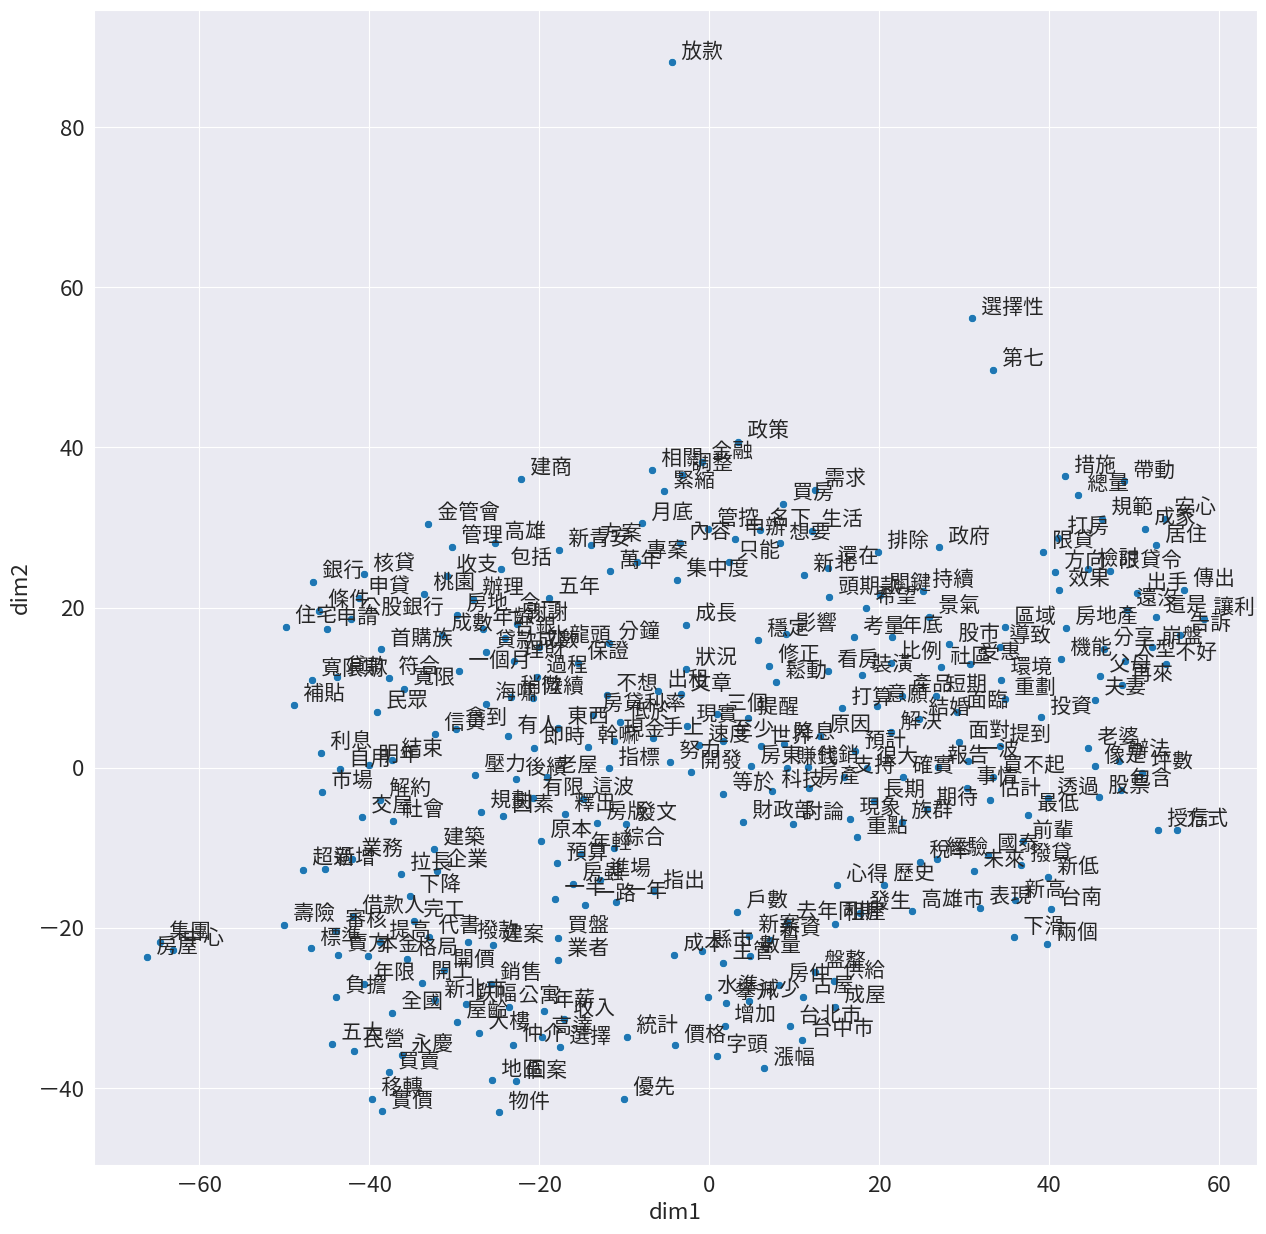

In [ ]:
plotScatter(word_df)

* 右上區域主要為政策與信用管制語意，反映央行與政府對房市的高強度干預。  
  詞彙如：「選擇性」、「第七」、「限貸令」、「打房」、「規範」、「出手」，顯示討論集中在限貸與管制措施。
* 左上至中左區域聚焦新青安與銀行執行面，屬於制度與申貸實務核心。  
  詞彙如：「新青安」、「寬限期」、「五年」、「金管會」、「公股銀行」、「核貸」、「首購族」，反映貸款條件與審核機制。
* 左下區域為實務交易與房仲市場行為，從政策轉向實際買賣。  
  詞彙如：「實價」、「物件」、「買賣」、「仲介」、「永慶」、「信義」，顯示查價與看房等交易活動。
* 右下區域則為區域房價與漲幅比較，帶有價格焦慮與期待。  
  詞彙如：「台北市」、「台中市」、「高雄市」、「台南市」、「漲幅」、「重劃區」，反映各地房價變動討論。
* 右側中間區域連結總體經濟與投資環境。詞彙如：「股市」、「景氣」、「環境」、「投資」，顯示房市與金融市場的連動分析。

3D 散狀圖

In [ ]:
new_feat = reduceDim(feat,dim = 3,method = 'PCA' )
print(new_feat.shape)
word_df = pd.DataFrame({
    "word":sample_words,
    "dim1":new_feat[:,0],
    "dim2":new_feat[:,1],
    "dim3":new_feat[:,2],
})
plotScatter3D(word_df)

(300, 3)


將字分群

In [ ]:
!pip install scikit-learn-extra

In [ ]:
# 分群
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
# 只使用word vector 去分群
def cluster(X,method = 'kmeans',n = 2):

    method_dict = {
        'kmeans':KMeans(n_clusters=n, random_state=0),
        'kmedos':KMedoids(n_clusters=n, random_state=0)
    }
    method_dict[method].fit(X)
    result = method_dict[method].predict(X)
    return result


In [ ]:
new_feat = reduceDim(feat,method='PCA',dim = 20)
d3_feat = reduceDim(feat,method='PCA',dim = 3)
word_df = pd.DataFrame({
    "word":sample_words,
    "color":cluster(new_feat,n=4),
    "dim1":d3_feat[:,0],
    "dim2":d3_feat[:,1],
    "dim3":d3_feat[:,2],

})
plotScatter3D(word_df)

* 藍色區域：多為與購屋主體相關的詞彙，如青年、安心、成家、年輕人、居住、打房、預售、房價。  
反映新青安保障的剛需族群，在面對市場變動時的心理預期。
* 紫色區域：多為與不動產買賣結果相關的詞彙，如買賣、永慶、信義、單價、總價、趨勢、統計、棟數。  
多出現在討論實價登錄與房仲成交量的現實語境中。
* 黃色區域：多為與銀行端資源配置相關的詞彙，如放款、集中度、不動產、第條、資源、壽險。  
顯示鄉民高度關注銀行水位吃緊與限貸令所帶來的金流風險。
* 橘色點：以管制為核心（鄰近利率、銀行），自成一個極端變數。  
代表央行信用管制是整個語意空間中最具獨立性與衝擊力的宏觀政策重錘。

### Transformers Embeddings
使用 Sentence-Transformer 套件
參考資料：https://www.sbert.net/index.html

In [ ]:
!pip install -U sentence-transformers

In [ ]:
%pip install sentencepiece

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from sentence_transformers import SentenceTransformer, models, util

In [ ]:
df_similar = origin_data[['system_id','artTitle', 'artContent']]
df_similar['artContent'] = df_similar['artContent'].apply(lambda x: re.sub('[^\u4e00-\u9fff]+', '',x))

df_similar.head(5)

C:\Users\orika\AppData\Local\Temp\ipykernel_17976\852741673.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_similar['artContent'] = df_similar['artContent'].apply(lambda x: re.sub('[^\u4e00-\u9fff]+', '',x))


,system_id,artTitle,artContent
0,1,[閒聊]中古屋都是誰在買？,年輕人愛好新房子買預售屋還款壓力小配合新青安很容易就能成家立業可以客變不用擔心管線老舊好奇中...
1,2,[請益]房貸方案請益,各位前輩好最近準備要辦理房貸目前評估以下兩個方案想請教大家的建議貸款人是先生太太名下有房貸以...
2,3,[新聞]顏炳立炮轟台灣房市「假買氣、真炒作」,連結內文年房市虎頭蛇尾今年房市走向如何消費者能期待降價嗎戴德梁行董事總經理顏炳立日表示年的房...
3,4,[新聞]國銀不動產貸款改善計畫央行：明年1月,連結內文國銀不動產貸款改善計畫央行明年月應可全數補齊中央社記者潘姿羽央行要求家國銀提出自主管...
4,5,[新聞]虛坪改革有譜?內政部允諾今年一定有作為,連結內文虛坪改革有譜內政部允諾今年一定有所作為徐筱嵐年月日週四下午備受外界期待的虛坪改革方案...


In [ ]:
# 中文 bert-base-chinese
bert_ch = SentenceTransformer('google-bert/bert-base-chinese')

bert_ch.tokenizer.add_special_tokens({'pad_token': '[PAD]'})

0

In [ ]:

corpus_embeddings = bert_ch.encode(
    df_similar['artContent'].tolist(),
    convert_to_tensor=True,
    batch_size=32
)

In [ ]:
query_num = 6 # 指定文章

# Find the closest 5 sentences of the corpus for each query sentence based on cosine similarity
top_k = 5


query_embedding = bert_ch.encode(df_similar['artContent'][query_num], convert_to_tensor=True)

# We use cosine-similarity and torch.topk to find the highest 5 scores
cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0]
top_results = torch.topk(cos_scores, k=top_k)

print("\n\n======================\n\n")
print("Query:", df_similar['artTitle'][query_num])
print("\n 資料集中前五相似的文章:")

for score, idx in zip(top_results[0], top_results[1]):
    print(df_similar['artTitle'][idx.item()], "(Score: {:.4f})".format(score))

print("\n\n======================\n\n")





Query: [閒聊]2025南科包租公逃跑潮

 資料集中前五相似的文章:
[閒聊]2025南科包租公逃跑潮 (Score: 1.0000)
[新聞]財經青紅燈》越晚買房越便宜？ (Score: 0.9510)
[閒聊]台北市低總交易分享 (Score: 0.9509)
Re:[閒聊]近期房市看法 (Score: 0.9497)
Re:[閒聊]錯過這班車，可能連後代都註定租一輩子 (Score: 0.9469)






In [ ]:
query_num = 30

top_k = 5

query_embedding = bert_ch.encode(df_similar['artContent'][query_num], convert_to_tensor=True)

# We use cosine-similarity and torch.topk to find the highest 5 scores
cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0]
top_results = torch.topk(cos_scores, k=top_k)

print("\n\n======================\n\n")
print("Query:", df_similar['artTitle'][query_num])
print("\n 資料集中前五相似的文章:")

for score, idx in zip(top_results[0], top_results[1]):
    print(df_similar['artTitle'][idx.item()], "(Score: {:.4f})".format(score))

print("\n\n======================\n\n")





Query: [新聞]寶佳推案量全台最多評價真的有那麼差嗎?

 資料集中前五相似的文章:
[新聞]寶佳推案量全台最多評價真的有那麼差嗎? (Score: 1.0000)
[新聞]半年賣三成就算及格?市調揭2026年房市新 (Score: 0.9836)
[新聞]建商怕買方躲專家：明年房市沒人是贏家 (Score: 0.9831)
[新聞]等不到降價這區晚一年買房得再多付5百萬 (Score: 0.9811)
[新聞]交屋大潮來了！前五月使照爆量破5.5萬戶 (Score: 0.9809)






<h1>分類任務</h1>
以PTT不同看板(loan、home_sale)找尋"新青安"相關訊息

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [ ]:
from sentence_transformers import SentenceTransformer, models, util

In [ ]:
df1 = pd.read_csv("homesale_loan.csv")
df1.head(3)

,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource
0,1,https://www.ptt.cc/bbs/home-sale/M.1735694794....,[閒聊]中古屋都是誰在買？,2025-01-01 09:26:32,qazxsw123,home_sale,年輕人愛好新房子\n\n買預售屋還款壓力小\n\n配合新青安很容易就能成家立業\n\n可以客...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""toto123"", ""c...",42.79.64.201,2025-02-21 15:24:49,ptt
1,2,https://www.ptt.cc/bbs/home-sale/M.1735798314....,[請益]房貸方案請益,2025-01-02 14:11:52,julie80211,home_sale,各位前輩好，最近準備要辦理房貸，目前評估以下兩個方案，想請教大家的建議。\n貸款人是先生，太...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""hellovega"", ...",42.79.178.218,2025-02-21 15:25:25,ptt
2,3,https://www.ptt.cc/bbs/home-sale/M.1735826693....,[新聞]顏炳立炮轟台灣房市「假買氣、真炒作」,2025-01-02 22:04:48,troy30408,home_sale,連結：\nhttps://money.udn.com/money/story/5621/84...,"[{""cmtStatus"": ""噓"", ""cmtPoster"": ""luben"", ""cmt...",61.228.240.13,2025-02-21 15:25:25,ptt


In [ ]:
# 過濾 nan 的資料
df1 = df1.dropna(subset=['artTitle'])
df1 = df1.dropna(subset=['artContent'])
# 移除網址格式
df1["artContent"] = df1.artContent.apply(
    lambda x: re.sub("(http|https)://.*", "", x)
)
df1["artTitle"] = df1["artTitle"].apply(
    lambda x: re.sub("(http|https)://.*", "", x)
)
# 只留下中文字
df1["artContent"] = df1.artContent.apply(
    lambda x: re.sub("[^\u4e00-\u9fa5]+", "", x)
)
df1["artTitle"] = df1["artTitle"].apply(
    lambda x: re.sub("[^\u4e00-\u9fa5]+", "", x)
)

# 留下 content
df1["content"] = df1["artTitle"] + df1["artContent"]
df1 = df1[["content", "artUrl", "artCatagory"]]  # 文章內容 文章連結
df1.head()

,content,artUrl,artCatagory
0,閒聊中古屋都是誰在買年輕人愛好新房子買預售屋還款壓力小配合新青安很容易就能成家立業可以客變不...,https://www.ptt.cc/bbs/home-sale/M.1735694794....,home_sale
1,請益房貸方案請益各位前輩好最近準備要辦理房貸目前評估以下兩個方案想請教大家的建議貸款人是先生...,https://www.ptt.cc/bbs/home-sale/M.1735798314....,home_sale
2,新聞顏炳立炮轟台灣房市假買氣真炒作連結內文年房市虎頭蛇尾今年房市走向如何消費者能期待降價嗎戴...,https://www.ptt.cc/bbs/home-sale/M.1735826693....,home_sale
3,新聞國銀不動產貸款改善計畫央行明年月連結內文國銀不動產貸款改善計畫央行明年月應可全數補齊中央...,https://www.ptt.cc/bbs/home-sale/M.1735860122....,home_sale
4,新聞虛坪改革有譜內政部允諾今年一定有作為連結內文虛坪改革有譜內政部允諾今年一定有所作為徐筱嵐...,https://www.ptt.cc/bbs/home-sale/M.1735866787....,home_sale


使用Bert做encoding

In [ ]:
texts_to_encode = df1['content'].tolist()
embeddings = bert_ch.encode(
    texts_to_encode,
    batch_size=128,
    show_progress_bar=True
)
df1['embeddings'] = list(embeddings)
df1.head(3)

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

,content,artUrl,artCatagory,embeddings
0,閒聊中古屋都是誰在買年輕人愛好新房子買預售屋還款壓力小配合新青安很容易就能成家立業可以客變不...,https://www.ptt.cc/bbs/home-sale/M.1735694794....,home_sale,"[0.42407385, -0.10889035, -0.036186468, 0.0964..."
1,請益房貸方案請益各位前輩好最近準備要辦理房貸目前評估以下兩個方案想請教大家的建議貸款人是先生...,https://www.ptt.cc/bbs/home-sale/M.1735798314....,home_sale,"[0.45695332, 0.035067856, -0.109081805, 0.0716..."
2,新聞顏炳立炮轟台灣房市假買氣真炒作連結內文年房市虎頭蛇尾今年房市走向如何消費者能期待降價嗎戴...,https://www.ptt.cc/bbs/home-sale/M.1735826693....,home_sale,"[0.32264912, 0.20463684, -0.34738865, 0.079320..."


In [ ]:
import numpy as np
from ast import literal_eval

In [ ]:
data = df1.copy()

X = data["embeddings"].apply(pd.Series)
y = data["artCatagory"]

# 把整個資料集七三切
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=777
)

print(X_train.head())
print(y_train.head())

          0         1         2         3         4         5         6    \
414  0.581515  0.150977 -0.093620  0.359804 -0.030897 -0.017586 -0.132508   
746  0.500575 -0.038159 -0.162254 -0.000665 -0.230956 -0.172387 -0.085233   
840  0.310082  0.068973  0.116371  0.003807 -0.184927 -0.073353 -0.036993   
915  0.279978  0.015656  0.000661 -0.049398 -0.340800 -0.135449  0.149844   
962  0.561802  0.032510 -0.037798  0.012297 -0.354853 -0.104226 -0.115764   

          7         8         9    ...       758       759       760  \
414 -0.009644 -0.051530 -0.380840  ...  0.136317  0.013056  0.140155   
746  0.095547  0.214316 -0.163941  ...  0.259069 -0.141507  0.427996   
840  0.029676  0.183664 -0.183421  ...  0.302435 -0.095923  0.365728   
915 -0.006844  0.108225 -0.092106  ...  0.272393 -0.262442  0.301271   
962  0.032767  0.181103 -0.171582  ...  0.099185 -0.099964  0.419311   

          761       762       763       764       765       766       767  
414  0.155710 -0.130904 -0.1

In [ ]:
pd.Series(y_train).value_counts()

artCatagory
home_sale    519
Loan         209
Name: count, dtype: int64

In [ ]:
clf = LogisticRegression()
clf.fit(X_train, y_train)
clf

LogisticRegression()

In [ ]:
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)
print(y_pred[:10])

['home_sale' 'home_sale' 'home_sale' 'home_sale' 'home_sale' 'home_sale'
 'home_sale' 'home_sale' 'home_sale' 'home_sale']


In [ ]:
from sklearn.metrics import classification_report

In [ ]:
## Accuracy, Precision, Recall, F1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Loan       1.00      0.96      0.98        91
   home_sale       0.98      1.00      0.99       221

    accuracy                           0.99       312
   macro avg       0.99      0.98      0.98       312
weighted avg       0.99      0.99      0.99       312



# 第十二週：BERT
資料集介紹:
```
時間：2022/03/31 ~ 2026/05/13
來源：PTT 多個看板（主要為 home-sale、Gossiping、tax、WomenTalk、HatePolitics）
關鍵字：租補、租屋補助、租金補貼、租屋補貼、租金補助、房租補助、租賃補貼、300億租金補貼
資料筆數：795 筆
```
動機：
```
近年租金上漲、租屋負擔加重，使「租屋補助」成為台灣住宅政策討論中的重要議題。
政府推動租金補貼等政策，希望減輕租屋族壓力，但民眾在網路討論中也常提到申請資格、補助成效、房東配合度、租金是否被墊高等疑慮。
```


# PTT 租屋補助政策討論：資料前處理與 CKIP NER

本次實作的主題是「PTT 租屋補助政策討論」。我們使用整理好的 PTT 文章資料，進行中文文字前處理，並透過 CKIP 完成斷詞、詞性標註與命名實體識別。

在社群媒體分析中，原始文章通常不是可以直接丟進模型的乾淨資料。PTT 文章會包含標題、內文、引用文字、網址、系統字串、特殊符號與不同看板的發文格式。因此，在進行 NER 之前，需要先把資料整理成較一致的格式，再切成句子，讓模型可以穩定處理。



## 大綱

1. 套件與 CKIP 模型設定
2. 讀取 PTT 租屋補助政策討論資料
3. 資料前處理：清理文章與切割句子
4. CKIP 標註：WS、POS、NER
5. 儲存 CKIP 結果
6. 探索分析：GPE、ORG、PERSON 高頻實體
7. 初步觀察與限制

## 1. 套件與模型設定

本節先載入後續會用到的 Python 套件與 CKIP 工具。CKIP 是中研院開發的中文自然語言處理工具，本 notebook 使用它提供的三個功能：

- `WS`：中文斷詞，將句子切成詞。
- `POS`：詞性標註，判斷每個詞的詞性。
- `NER`：命名實體識別，找出句子中的人名、組織、地名等實體。

如果尚未安裝套件，可以用以下方式啟動 notebook：

```bash
uv run --with "ckiptagger[tf,gdown]" jupyter lab
```

如果尚未下載 CKIP 模型資料，可以先執行：

```python
from ckiptagger import data_utils
data_utils.download_data_gdown("./")
```

本資料夾目前已經有 `data/` 模型資料，因此可以直接載入 CKIP 模型。

In [ ]:
from pathlib import Path
import re
import time
import pandas as pd
import matplotlib.pyplot as plt
from ckiptagger import WS, POS, NER, construct_dictionary

DATA_PATH = Path('ptt_rent_subsidy_policy_discussions_direct.csv')
OUTPUT_DIR = Path('output/ner')
CKIP_DATA_DIR = Path('data')
KEEP_NER_TYPES = {'GPE', 'ORG', 'PERSON'}

pd.set_option('display.max_colwidth', 80)
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang TC', 'Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

## 2. 讀取資料與基本檢查

本次使用的資料檔是 `ptt_rent_subsidy_policy_discussions_direct.csv`。這份資料是從 PTT 多個討論型看板整理而來，篩選條件是文章中明確出現租屋補助相關詞，例如「租補」、「租屋補助」、「租金補貼」、「租屋補貼」等。

資料排除一般出租、求租與房源刊登文，也不包含 `Rent_apart` 看板。換句話說，這份資料的分析單位是「PTT 文章本文」，不是推文，也不是房源廣告。

讀取資料後，我們先確認三件事：

1. 文章總數是否正確。
2. 欄位是否包含後續分析需要的標題、內文與看板資訊。
3. 不同看板的資料量分布。

In [ ]:
df = pd.read_csv(DATA_PATH)
print('文章數：', len(df))
print('欄位：', list(df.columns))
df.head(3)

文章數： 795
欄位： ['post_datetime', 'board', 'title', 'title_tag', 'matched_keywords', 'content_raw', 'crawl_datetime']


,post_datetime,board,title,title_tag,matched_keywords,content_raw,crawl_datetime
0,2026-05-13 10:31:11,tax,[新聞] 國土署啟動租補追繳！33名失聯戶名單曝、,新聞,租補、租金補貼,國土署啟動租補追繳！33名失聯戶名單曝、最高得繳回近5萬元\n2026-05-12 13:35 經濟日報／ 記者胡順惠 ／台北即時報導\nhttps:/...,2026-05-15 23:28:28
1,2026-05-08 15:12:50,Gossiping,[新聞] 檢舉房東逃漏稅別只給截圖 國稅局：沒這,新聞,租金補貼,備註請放最後面 違者新聞文章刪除\n1.媒體來源:\n※ 例如蘋果日報、自由時報（請參考版規下方的核准媒體名單）\n※ Yahoo、MSN、LINE等非...,2026-05-15 23:28:28
2,2026-05-07 17:59:59,home-sale,[閒聊] 申請房屋稅減免發現租補漏洞,閒聊,租補、租屋補貼,之前好幾年前我租給一個房客，她也是要租屋補貼，後來住了兩個月就說要搬，還要求退押金，坳不過她就全部退了！當時她一次簽了三年\n後來她沒住時里長還跑來問我...,2026-05-15 23:28:28


In [ ]:
board_count = df['board'].value_counts().reset_index()
board_count.columns = ['board', 'count']
board_count.head(15)

,board,count
0,home-sale,350
1,Gossiping,212
2,tax,93
3,WomenTalk,38
4,HatePolitics,27
5,Tainan,20
6,Kaohsiung,19
7,LAW,14
8,TaichungBun,11
9,Lifeismoney,5


## 3. 資料前處理

本節處理流程如下：

1. 將標題與內文合併成一個完整文本。
2. 移除網址、PTT 系統文字與不必要符號。
3. 保留中文、英文、數字與基本標點。
4. 依照句號、問號、驚嘆號、分號與換行切成句子。
5. 建立 `sentence_table`，作為 CKIP 模型輸入。

In [ ]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'※.*', ' ', text)
    text = re.sub(r'[\u200b\xa0]', ' ', text)
    text = re.sub(r'[^\u4e00-\u9fffA-Za-z0-9，。！？；：、,.!?;%％（）()「」『』\n ]+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def split_sentences(text):
    parts = re.split(r'[。！？!?；;\n]+', text)
    return [part.strip(' ，,、') for part in parts if len(part.strip()) >= 8]

posts = df.copy()
posts.insert(0, 'post_id', [f'post_{i:04d}' for i in range(1, len(posts) + 1)])
posts['raw_text'] = posts['title'].fillna('') + '\n' + posts['content_raw'].fillna('')
posts['clean_text'] = posts['raw_text'].map(clean_text)
posts['clean_length'] = posts['clean_text'].str.len()

posts[['post_id', 'board', 'title', 'matched_keywords', 'clean_length']].head()

,post_id,board,title,matched_keywords,clean_length
0,post_0001,tax,[新聞] 國土署啟動租補追繳！33名失聯戶名單曝、,租補、租金補貼,669
1,post_0002,Gossiping,[新聞] 檢舉房東逃漏稅別只給截圖 國稅局：沒這,租金補貼,891
2,post_0003,home-sale,[閒聊] 申請房屋稅減免發現租補漏洞,租補、租屋補貼,398
3,post_0004,tax,[新聞] 國土署：租補核定破83萬戶 個別縣市審查,租補、租金補貼,889
4,post_0005,tax,[新聞] 租屋族報稅會被房東發現嗎？ 專家教戰3大,租屋補助,1087


In [ ]:
sentence_rows = []
for row in posts.itertuples(index=False):
    for sentence_idx, sentence in enumerate(split_sentences(row.clean_text), start=1):
        sentence_rows.append({
            'post_id': row.post_id,
            'board': row.board,
            'sentence_id': f'{row.post_id}_s{sentence_idx:03d}',
            'sentence_order': sentence_idx,
            'text': sentence,
        })

sentence_table = pd.DataFrame(sentence_rows)
print('句子數：', len(sentence_table))
sentence_table.head(10)

句子數： 7910


,post_id,board,sentence_id,sentence_order,text
0,post_0001,tax,post_0001_s001,1,新聞 國土署啟動租補追繳
1,post_0001,tax,post_0001_s002,2,33名失聯戶名單曝、 國土署啟動租補追繳
2,post_0001,tax,post_0001_s003,3,33名失聯戶名單曝、最高得繳回近5萬元 2026 05 12 13 35 經濟日報 記者胡順惠 台北即時報導 租金補貼案件中，不少涉及追回溢領租金補貼
3,post_0001,tax,post_0001_s004,4,圖 聯合報系資料照片 300億元中央擴大租金補貼出現部分補貼戶失聯、資格遭撤銷情況
4,post_0001,tax,post_0001_s005,5,內政部國土署最新公 告指出，共有33名租金補貼申請人因地址不明、無法聯繫，導致相關行政處分書與補件通 知無法送達，因此依法辦理「公示送達」，其中不少案件...
5,post_0001,tax,post_0001_s006,6,國土署表示，這次公示送達案件涵蓋2022年度及2023至2024年度「300億元中央擴大租金 補貼專案計畫」，原因包括申請人失聯、戶籍地址不明，或通知寄...
6,post_0001,tax,post_0001_s007,7,由於正 式文件無法交付當事人，因此依 行政程序法 規定，改以公告方式通知
7,post_0001,tax,post_0001_s008,8,從公告名冊來看，部分案件是申請人資格遭廢止或撤銷後，被要求返還已領取的租金補貼
8,post_0001,tax,post_0001_s009,9,也有案件是申請資料需補件，但因無法聯絡申請人，因此改採公示送達
9,post_0001,tax,post_0001_s010,10,另有部分案件 涉及申請人死亡，由國土署通知繼承人返還溢領補貼


## 4. CKIP 標註

完成清理與切句後，接著使用 CKIP 進行三個標註任務：

1. `WS`：將句子切成詞。
2. `POS`：為每個詞標上詞性。
3. `NER`：辨識句子中的命名實體。

本次任務關心的是三種實體：

- `GPE`：地緣政治實體，例如台灣、台北、新北、高雄。
- `ORG`：組織，例如內政部、國土署、行政院、國稅局。
- `PERSON`：人物，例如政治人物、政府官員、新聞人物。

另外，為了讓 CKIP 斷詞時不要把主題詞切碎，我們加入自訂詞典，例如「租屋補助」、「租金補貼」、「國土署」、「包租代管」。對應課堂 notebook 中使用 `construct_dictionary` 的方式。

In [ ]:
CKIP_WORDS = {
    '租補': 100,
    '租屋補助': 100,
    '租金補貼': 100,
    '租屋補貼': 100,
    '租金補助': 100,
    '房租補助': 100,
    '租賃補貼': 100,
    '300億租金補貼': 100,
    '社會住宅': 100,
    '社宅': 100,
    '包租代管': 100,
    '房屋稅': 100,
    '國土署': 100,
    '內政部': 100,
    '行政院': 100,
    '財政部': 100,
    '國稅局': 100,
    '住都中心': 100,
}

dictionary = construct_dictionary(CKIP_WORDS)
print(dictionary)

[(2, {'租補': 100.0, '社宅': 100.0}), (3, {'房屋稅': 100.0, '國土署': 100.0, '內政部': 100.0, '行政院': 100.0, '財政部': 100.0, '國稅局': 100.0}), (4, {'租屋補助': 100.0, '租金補貼': 100.0, '租屋補貼': 100.0, '租金補助': 100.0, '房租補助': 100.0, '租賃補貼': 100.0, '社會住宅': 100.0, '包租代管': 100.0, '住都中心': 100.0}), (8, {'300億租金補貼': 100.0})]


In [ ]:
ws = WS(str(CKIP_DATA_DIR))
pos = POS(str(CKIP_DATA_DIR))
ner = NER(str(CKIP_DATA_DIR))

/usr/local/lib/python3.12/dist-packages/ckiptagger/model_ws.py:106: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.compat.v1.nn.rnn_cell.LSTMCell(hidden_d, name=name)
/usr/local/lib/python3.12/dist-packages/ckiptagger/model_pos.py:56: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.compat.v1.nn.rnn_cell.LSTMCell(hidden_d, name=name)
/usr/local/lib/python3.12/dist-packages/ckiptagger/model_ner.py:57: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.compat.v1.nn.rnn_cell.LSTMCell(hidden_d, name=name)


In [ ]:
def run_ckip(sentence_table, batch_size=256):
    pos_rows = []
    entity_rows = []
    total = len(sentence_table)
    start_time = time.time()

    for start in range(0, total, batch_size):
        batch = sentence_table.iloc[start:start + batch_size]
        sentence_list = batch['text'].tolist()

        word_sentence_list = ws(sentence_list, coerce_dictionary=dictionary)
        pos_sentence_list = pos(word_sentence_list)
        entity_sentence_list = ner(word_sentence_list, pos_sentence_list)

        for meta, word_sentence, pos_sentence, entity_sentence in zip(
            batch.itertuples(index=False),
            word_sentence_list,
            pos_sentence_list,
            entity_sentence_list,
        ):
            for word, pos_tag in zip(word_sentence, pos_sentence):
                if word.strip():
                    pos_rows.append({
                        'post_id': meta.post_id,
                        'board': meta.board,
                        'sentence_id': meta.sentence_id,
                        'word': word,
                        'pos': pos_tag,
                    })

            for entity in sorted(entity_sentence):
                ner_type = entity[2]
                if ner_type not in KEEP_NER_TYPES:
                    continue
                entity_rows.append({
                    'post_id': meta.post_id,
                    'board': meta.board,
                    'sentence_id': meta.sentence_id,
                    'entity': entity[3],
                    'ner': ner_type,
                    'start': entity[0],
                    'end': entity[1],
                    'sentence': meta.text,
                })

        done = min(start + batch_size, total)
        print(f'CKIP 已處理 {done}/{total} 句，耗時 {time.time() - start_time:.1f} 秒')

    return pd.DataFrame(pos_rows), pd.DataFrame(entity_rows)

In [ ]:
pos_table, entity_table = run_ckip(sentence_table, batch_size=256)
print('CKIP 斷詞 / POS 筆數：', len(pos_table))
print('CKIP NER 實體筆數：', len(entity_table))
entity_table.head(10)

CKIP 已處理 256/7910 句，耗時 58.5 秒
CKIP 已處理 512/7910 句，耗時 128.6 秒
CKIP 已處理 768/7910 句，耗時 207.7 秒
CKIP 已處理 1024/7910 句，耗時 268.8 秒
CKIP 已處理 1280/7910 句，耗時 328.5 秒
CKIP 已處理 1536/7910 句，耗時 393.0 秒
CKIP 已處理 1792/7910 句，耗時 468.4 秒
CKIP 已處理 2048/7910 句，耗時 537.6 秒
CKIP 已處理 2304/7910 句，耗時 607.8 秒
CKIP 已處理 2560/7910 句，耗時 678.4 秒
CKIP 已處理 2816/7910 句，耗時 734.1 秒
CKIP 已處理 3072/7910 句，耗時 832.4 秒
CKIP 已處理 3328/7910 句，耗時 944.9 秒
CKIP 已處理 3584/7910 句，耗時 1017.4 秒
CKIP 已處理 3840/7910 句，耗時 1216.4 秒
CKIP 已處理 4096/7910 句，耗時 1356.4 秒
CKIP 已處理 4352/7910 句，耗時 1432.5 秒
CKIP 已處理 4608/7910 句，耗時 1496.7 秒
CKIP 已處理 4864/7910 句，耗時 1578.0 秒
CKIP 已處理 5120/7910 句，耗時 1640.2 秒
CKIP 已處理 5376/7910 句，耗時 1734.6 秒
CKIP 已處理 5632/7910 句，耗時 1806.9 秒
CKIP 已處理 5888/7910 句，耗時 1881.1 秒
CKIP 已處理 6144/7910 句，耗時 1945.1 秒
CKIP 已處理 6400/7910 句，耗時 2057.8 秒
CKIP 已處理 6656/7910 句，耗時 2130.9 秒
CKIP 已處理 6912/7910 句，耗時 2238.3 秒
CKIP 已處理 7168/7910 句，耗時 2381.1 秒
CKIP 已處理 7424/7910 句，耗時 2476.4 秒
CKIP 已處理 7680/7910 句，耗時 2567.3 秒
CKIP 已處理 7910/7910 句，耗時 263

,post_id,board,sentence_id,entity,ner,start,end,sentence
0,post_0001,tax,post_0001_s001,國土署,ORG,3,6,新聞 國土署啟動租補追繳
1,post_0001,tax,post_0001_s003,胡順惠,PERSON,44,47,33名失聯戶名單曝、最高得繳回近5萬元 2026 05 12 13 35 經濟日報 記者胡順惠 台北即時報導 租金補貼案件中，不少涉及追回溢領租金補貼
2,post_0001,tax,post_0001_s003,台北,GPE,48,50,33名失聯戶名單曝、最高得繳回近5萬元 2026 05 12 13 35 經濟日報 記者胡順惠 台北即時報導 租金補貼案件中，不少涉及追回溢領租金補貼
3,post_0001,tax,post_0001_s004,聯合報系,ORG,2,6,圖 聯合報系資料照片 300億元中央擴大租金補貼出現部分補貼戶失聯、資格遭撤銷情況
4,post_0001,tax,post_0001_s005,內政部,ORG,0,3,內政部國土署最新公 告指出，共有33名租金補貼申請人因地址不明、無法聯繫，導致相關行政處分書與補件通 知無法送達，因此依法辦理「公示送達」，其中不少案件...
5,post_0001,tax,post_0001_s006,國土署,ORG,0,3,國土署表示，這次公示送達案件涵蓋2022年度及2023至2024年度「300億元中央擴大租金 補貼專案計畫」，原因包括申請人失聯、戶籍地址不明，或通知寄...
6,post_0001,tax,post_0001_s010,國土署,ORG,16,19,另有部分案件 涉及申請人死亡，由國土署通知繼承人返還溢領補貼
7,post_0001,tax,post_0001_s012,國土署,ORG,0,3,國土署指出，公告已刊登於行政院公報，並同步張貼於各地方政府公告欄
8,post_0001,tax,post_0001_s012,行政院,ORG,12,15,國土署指出，公告已刊登於行政院公報，並同步張貼於各地方政府公告欄
9,post_0001,tax,post_0001_s013,國土署住宅發展組,ORG,26,34,相關當事人可 在辦公時間內，攜帶身分證件及印章，前往國土署住宅發展組領取文件


## 5. 儲存 CKIP 結果

CKIP 執行完後，會產生多種表格。把不同分析層級分開儲存。

主要輸出包含：

- `clean_posts.csv`：清理後的文章層級資料。
- `sentence_table.csv`：句子層級資料，每列是一個句子。
- `pos_table.csv`：CKIP 斷詞與詞性標註結果。
- `entity_table.csv`：CKIP NER 結果，每列是一個實體。
- `entity_summary.csv`：各類實體的出現次數與文章數。
- `board_entity_summary.csv`：不同看板中的實體類型分布。

這樣拆開的好處是，後續如果要做情緒分析、主題模型或看板比較，可以直接使用對應層級的表格。

In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
posts.to_csv(OUTPUT_DIR / 'clean_posts.csv', index=False, encoding='utf-8-sig')
sentence_table.to_csv(OUTPUT_DIR / 'sentence_table.csv', index=False, encoding='utf-8-sig')
pos_table.to_csv(OUTPUT_DIR / 'pos_table.csv', index=False, encoding='utf-8-sig')
entity_table.to_csv(OUTPUT_DIR / 'entity_table.csv', index=False, encoding='utf-8-sig')

# 原始 CKIP 斷詞會包含標點、功能詞、數字與新聞格式詞，因此先保留 raw 版本，再建立內容詞版本。
token_frequency_raw = pos_table['word'].value_counts().rename_axis('word').reset_index(name='count')
token_frequency_raw.to_csv(OUTPUT_DIR / 'token_frequency_raw.csv', index=False, encoding='utf-8-sig')

keep_pos_prefixes = ('Na', 'Nb', 'Nc', 'VA', 'VB', 'VC', 'VD', 'VE', 'VH', 'VJ', 'VK')
stopwords = {
    '新聞','問卦','閒聊','請益','問題','討論','心得','情報','完整','標題','內文','備註','媒體','來源','記者','署名','連結','作者','看板','時間','文章','引述','Sent','from','http','https',
    '一個','一些','一下','不是','可以','因為','所以','如果','但是','就是','沒有','自己','覺得','真的','這個','那個','還是','可能','現在','大家','很多','有人','什麼','怎麼','為什麼','是不是','有沒有','不要','應該',
    '的','是','不','有','我','就','也','一','在','了','要','個','這','都','會','你','說','人','但','還','他','沒','跟','能','讓','很','被','來','可','到','與','去','為','再','或','及','對','上','想','等','後','好','才','那','多','年','月','元','戶','房','租',
    '表示','指出','認為','直言','呼籲','強調','報導','發布','今日','目前','今年','去年','近期','相關','部分','其中','以及','包括','透過','進行','使用','需要','成為','持續','提供','取得','增加','減少','看到','知道',
    '房東','租客','租屋'
}

content_pos_table = pos_table[
    pos_table['pos'].astype(str).str.startswith(keep_pos_prefixes) &
    pos_table['word'].astype(str).str.len().ge(2) &
    ~pos_table['word'].astype(str).isin(stopwords) &
    ~pos_table['word'].astype(str).str.fullmatch(r'[0-9A-Za-z._%-]+') &
    ~pos_table['word'].astype(str).str.fullmatch(r'\d+[年月日萬億千百]?') &
    ~pos_table['word'].astype(str).str.contains(r'^[，。、：；！？「」『』（）()\[\]【】,.!?%]+$', regex=True)
].copy()
content_pos_table.to_csv(OUTPUT_DIR / 'content_pos_table.csv', index=False, encoding='utf-8-sig')

token_frequency = content_pos_table['word'].value_counts().rename_axis('word').reset_index(name='count')
token_frequency.to_csv(OUTPUT_DIR / 'token_frequency.csv', index=False, encoding='utf-8-sig')

entity_summary = (
    entity_table.groupby(['ner', 'entity'])
    .agg(count=('entity', 'size'), post_count=('post_id', 'nunique'))
    .reset_index()
    .sort_values(['ner', 'count', 'post_count'], ascending=[True, False, False])
)
entity_summary.to_csv(OUTPUT_DIR / 'entity_summary.csv', index=False, encoding='utf-8-sig')

board_entity_summary = (
    entity_table.groupby(['board', 'ner'])
    .agg(count=('entity', 'size'), entity_count=('entity', 'nunique'))
    .reset_index()
    .sort_values(['board', 'count'], ascending=[True, False])
)
board_entity_summary.to_csv(OUTPUT_DIR / 'board_entity_summary.csv', index=False, encoding='utf-8-sig')

print('輸出資料夾：', OUTPUT_DIR.resolve())
print('原始斷詞筆數：', len(pos_table))
print('內容詞筆數：', len(content_pos_table))

輸出資料夾： /content/output/ner
原始斷詞筆數： 354117
內容詞筆數： 122897


## 6. 讀取已完成的 CKIP 結果

CKIP 模型執行時間較長，因此實務上通常不會每次分析都重新跑模型。第一次完成標註後，可以把結果存成 CSV，後續直接讀取已完成的 `pos_table` 和 `entity_table`。

這一節的目的，是讓 notebook 可以分成兩種使用方式：

1. 從原始文章重新跑 CKIP。
2. 直接讀取已經完成的 CKIP 標註結果。

In [ ]:
pos_table = pd.read_csv(OUTPUT_DIR / 'pos_table.csv')
entity_table = pd.read_csv(OUTPUT_DIR / 'entity_table.csv')
sentence_table = pd.read_csv(OUTPUT_DIR / 'sentence_table.csv')
entity_summary = pd.read_csv(OUTPUT_DIR / 'entity_summary.csv')
board_entity_summary = pd.read_csv(OUTPUT_DIR / 'board_entity_summary.csv')

print('POS 筆數：', len(pos_table))
print('NER 筆數：', len(entity_table))
print('NER 類別：', entity_table['ner'].value_counts().to_dict())

POS 筆數： 354117
NER 筆數： 8473
NER 類別： {'ORG': 3195, 'PERSON': 2867, 'GPE': 2411}


## 7. 探索分析：NER 類別與高頻實體

- `GPE`：地緣政治實體。
- `ORG`：組織。
- `PERSON`：人物。

我們先統計三類實體的總數，再分別列出每一類最常出現的實體。這可以幫助我們了解 PTT 討論租屋補助政策時，最常被提到的地方、政府單位與人物。

In [ ]:
entity_type_count = entity_table['ner'].value_counts().reset_index()
entity_type_count.columns = ['ner', 'count']
entity_type_count

,ner,count
0,ORG,3195
1,PERSON,2867
2,GPE,2411


In [ ]:
for ner_type in ['GPE', 'ORG', 'PERSON']:
    print(f'\n{ner_type}')
    display(entity_summary[entity_summary['ner'] == ner_type].head(15))


GPE


,ner,entity,count,post_count
0,GPE,台灣,367,150
1,GPE,台北,252,173
2,GPE,高雄,170,50
3,GPE,台北市,139,84
4,GPE,北市,101,35
5,GPE,台中,89,32
6,GPE,台南,81,29
7,GPE,台,65,50
8,GPE,新北市,65,43
9,GPE,桃園,57,32



ORG


,ner,entity,count,post_count
326,ORG,內政部,771,267
327,ORG,中央,184,80
328,ORG,行政院,164,96
329,ORG,國土署,114,38
330,ORG,財政部,94,43
331,ORG,營建署,82,33
332,ORG,立法院,78,50
333,ORG,民進黨,71,45
334,ORG,國稅局,70,40
335,ORG,崔媽媽基金會,52,26



PERSON


,ner,entity,count,post_count
859,PERSON,劉世芳,202,59
860,PERSON,賴清德,157,49
861,PERSON,柯文哲,100,16
862,PERSON,蔡英文,82,44
863,PERSON,蔡,81,33
864,PERSON,花敬群,60,17
865,PERSON,賴,56,31
866,PERSON,黃國昌,51,12
867,PERSON,陳其邁,49,19
868,PERSON,新青安,48,27


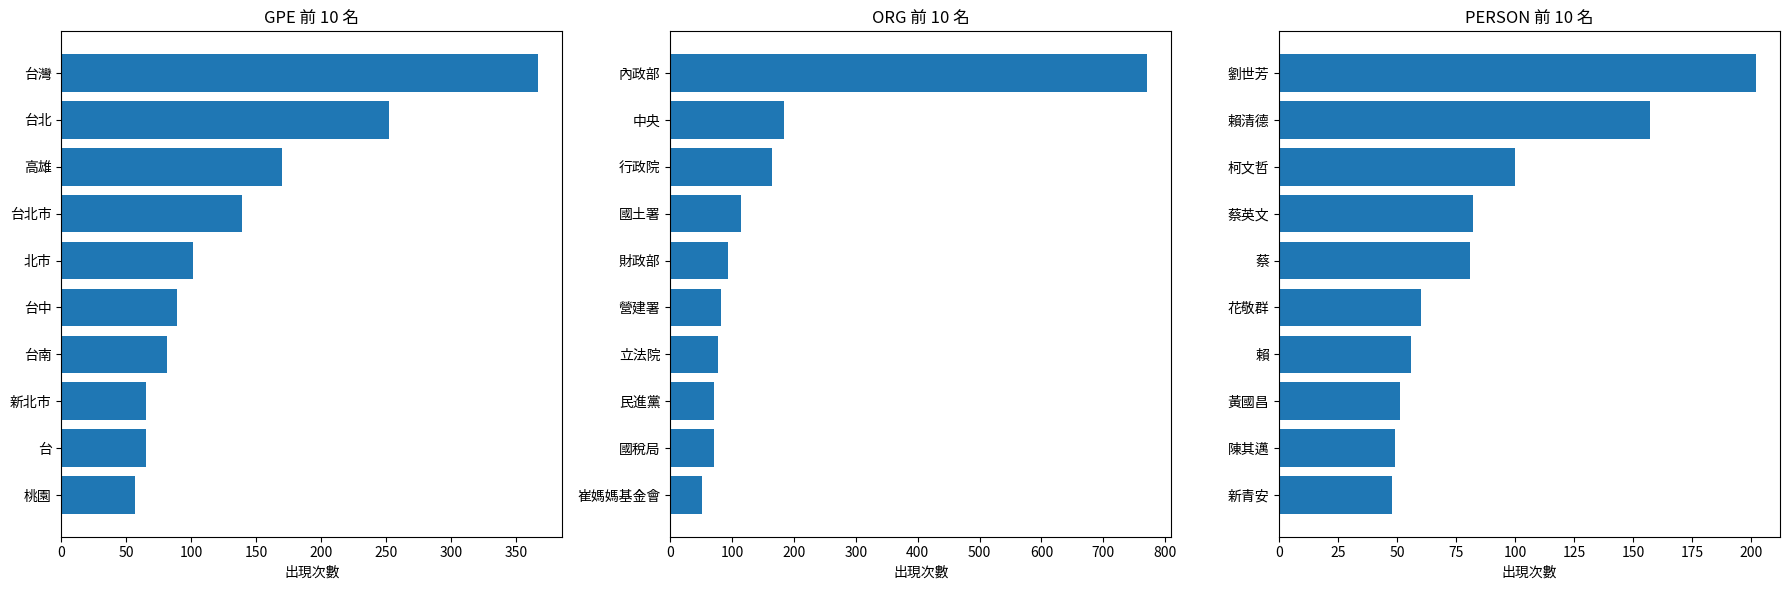

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, ner_type in zip(axes, ['GPE', 'ORG', 'PERSON']):
    plot_df = entity_summary[entity_summary['ner'] == ner_type].head(10).sort_values('count')
    ax.barh(plot_df['entity'], plot_df['count'])
    ax.set_title(f'{ner_type} 前 10 名')
    ax.set_xlabel('出現次數')
plt.tight_layout()
plt.show()

In [ ]:
board_entity_summary.head(30)

,board,ner,count,entity_count
0,BabyMother,ORG,1,1
1,CFP,ORG,9,4
2,CFP,GPE,3,1
3,CFP,PERSON,1,1
4,Gossiping,PERSON,902,230
5,Gossiping,ORG,869,169
6,Gossiping,GPE,489,108
7,HatePolitics,PERSON,231,41
8,HatePolitics,ORG,121,33
9,HatePolitics,GPE,46,19


## 8. 圖表整理

除了表格統計之外，這裡也把主要結果畫成圖，方便快速觀察資料來源與 CKIP NER 結果。

圖表包含：

1. 各看板文章數。
2. `GPE / ORG / PERSON` 三類實體數量。
3. 三類實體各自的前 10 名高頻詞。
4. CKIP 斷詞後的「內容詞」前 20 名。

注意：原始 CKIP 斷詞會包含標點、功能詞、數字與新聞格式詞，所以高頻詞圖不直接使用 raw token，而是先透過 POS 與停用字表過濾後再計算。

In [ ]:
from pathlib import Path
fig_dir = OUTPUT_DIR / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

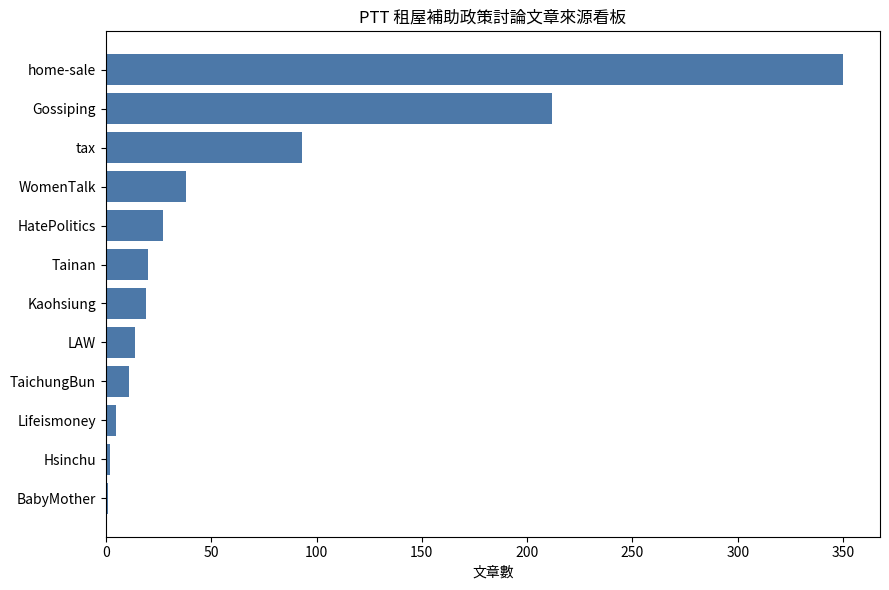

In [ ]:
# 看板文章數
board_count = posts['board'].value_counts().reset_index()
board_count.columns = ['board', 'count']
plot_df = board_count.head(12).sort_values('count')

plt.figure(figsize=(9, 6))
plt.barh(plot_df['board'], plot_df['count'], color='#4C78A8')
plt.title('PTT 租屋補助政策討論文章來源看板')
plt.xlabel('文章數')
plt.tight_layout()
plt.show()

從看板分布可以看出，資料主要集中在 `home-sale`、`Gossiping` 和 `tax`。這代表租屋補助政策討論不只出現在房市板，也會出現在八卦板的公共議題討論，以及稅務相關看板。

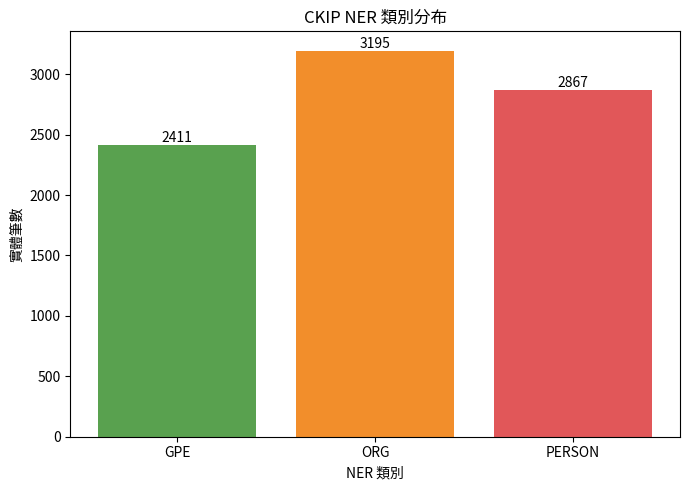

In [ ]:
# NER 類別分布
ner_count = entity_table['ner'].value_counts().reindex(['GPE', 'ORG', 'PERSON']).dropna().reset_index()
ner_count.columns = ['ner', 'count']

plt.figure(figsize=(7, 5))
plt.bar(ner_count['ner'], ner_count['count'], color=['#59A14F', '#F28E2B', '#E15759'])
plt.title('CKIP NER 類別分布')
plt.xlabel('NER 類別')
plt.ylabel('實體筆數')
for i, row in ner_count.iterrows():
    plt.text(i, row['count'], str(int(row['count'])), ha='center', va='bottom')
plt.tight_layout()
plt.show()

NER 類別分布可以幫助我們確認資料是否真的有足夠的實體訊息。這份資料中，`ORG`、`PERSON` 和 `GPE` 都有相當數量，代表政策討論中同時涉及政府機關、政治人物與地區名稱。

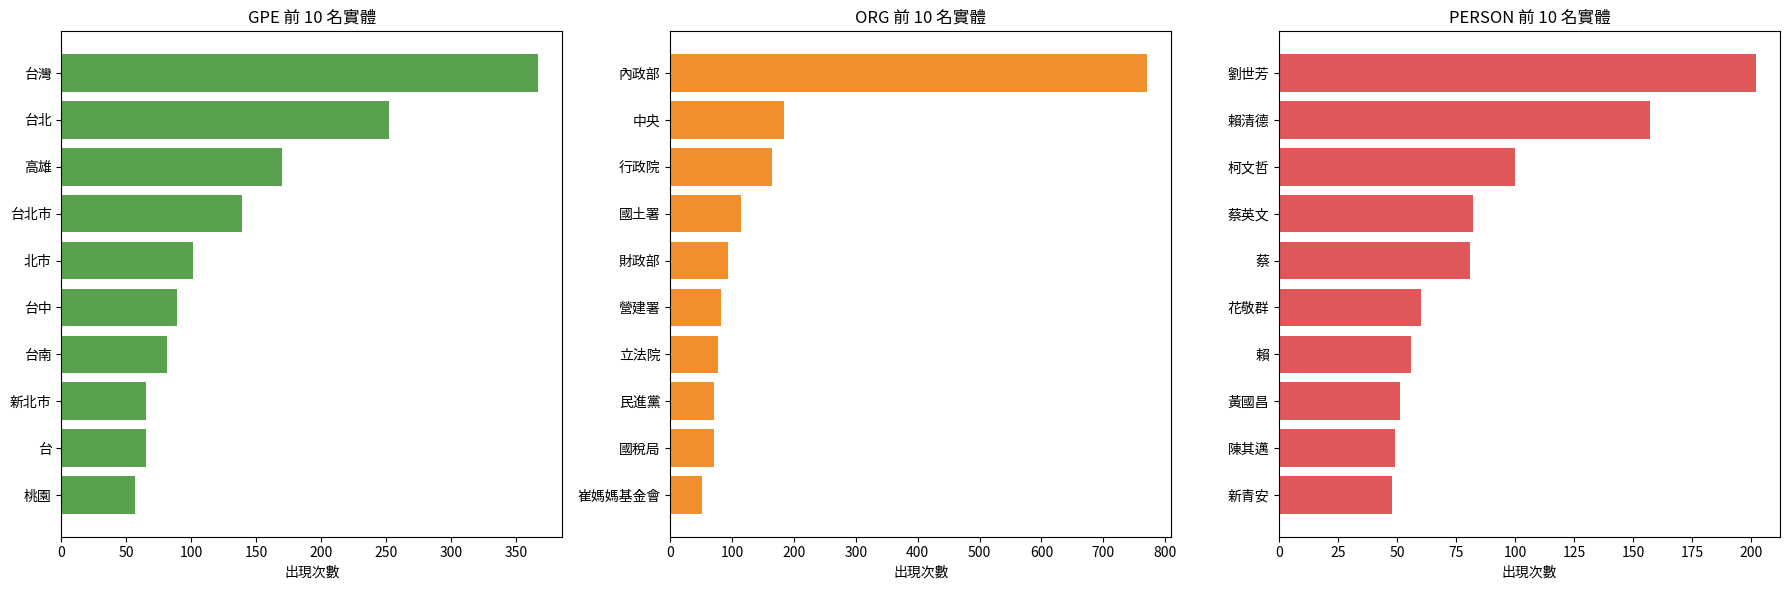

In [ ]:
# 各類實體前 10 名
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = {'GPE': '#59A14F', 'ORG': '#F28E2B', 'PERSON': '#E15759'}
for ax, ner_type in zip(axes, ['GPE', 'ORG', 'PERSON']):
    plot_df = entity_summary[entity_summary['ner'] == ner_type].head(10).sort_values('count')
    ax.barh(plot_df['entity'], plot_df['count'], color=colors[ner_type])
    ax.set_title(f'{ner_type} 前 10 名實體')
    ax.set_xlabel('出現次數')
plt.tight_layout()
plt.show()

高頻實體圖可以看出討論焦點。`GPE` 能指出討論常牽涉哪些地區；`ORG` 能指出政策責任單位或相關組織；`PERSON` 則能觀察哪些政治人物或新聞人物常被連到租屋補助討論。

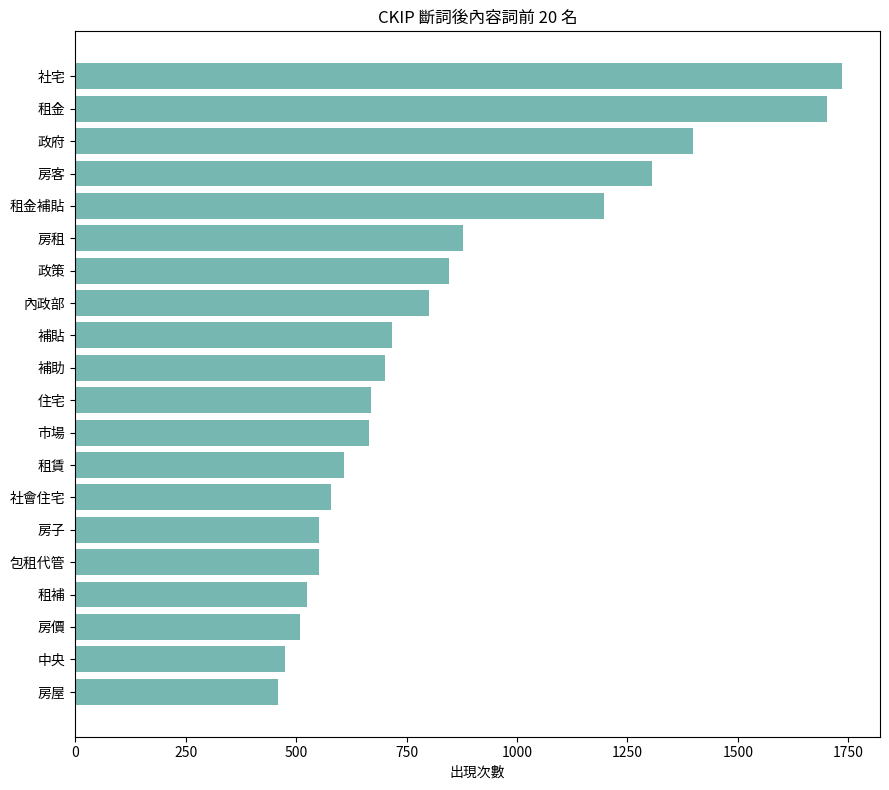

In [ ]:
# CKIP 斷詞後內容詞前 20 名
freq = pd.read_csv(OUTPUT_DIR / 'token_frequency.csv').head(20).sort_values('count')

plt.figure(figsize=(9, 8))
plt.barh(freq['word'], freq['count'], color='#76B7B2')
plt.title('CKIP 斷詞後內容詞前 20 名')
plt.xlabel('出現次數')
plt.tight_layout()
plt.show()

詞頻圖不是 NER 的核心結果，但可以作為資料品質檢查。這裡使用的是「內容詞高頻詞」，已先排除標點、功能詞、數字與新聞格式詞。若高頻詞大多和社宅、租金、租金補貼、政策、內政部、補助等主題相關，代表資料主題大致集中在租屋補助與住宅政策。

In [ ]:
import os
from google.colab import files

# 1. 定義你想下載的資料夾路徑，以及壓縮後的檔名
folder_to_zip = 'output/ner'
output_zip_file = 'output_ner_results.zip'

# 2. 檢查資料夾是否存在
if os.path.exists(folder_to_zip):
    print(f"正在壓縮資料夾 {folder_to_zip} ...")
    # 使用 Linux 指令進行壓縮：-r 代表遞迴壓縮資料夾內所有檔案，-q 代表安靜模式不印出長串清單
    !zip -r -q {output_zip_file} {folder_to_zip}

    print(f"壓縮完成！開始下載 {output_zip_file} ...")
    # 3. 觸發瀏覽器下載該 zip 檔
    files.download(output_zip_file)
else:
    print(f"錯誤：找不到資料夾 '{folder_to_zip}'，請確認路徑是否正確或前面步驟是否有成功生成資料夾。")

正在壓縮資料夾 output/ner ...
壓縮完成！開始下載 output_ner_results.zip ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. 初步觀察

從 CKIP NER 結果可以先整理出以下觀察：

1. `GPE` 常見實體包含台灣、台北、高雄、新北市等，代表租屋補助討論經常和地區租屋市場、地方加碼政策或地方居住壓力有關。
2. `ORG` 常見實體包含內政部、國土署、行政院、財政部、國稅局等，這些組織都與住宅政策、租金補貼、稅務制度或行政執行有關。
3. `PERSON` 常見實體多為政治人物、政府官員或新聞人物。這些人物出現，通常和政策責任、選舉承諾、社宅政策或租補爭議有關。
4. 本資料是文章本文分析，不包含推文。因此，這份結果適合觀察文章主題與政策討論脈絡，但還不能代表推文留言的即時反應。



## 9. Sequence classification

### 9.1 Sentiment Classification
使用 Huggingface 上面已經針對 Sentiment classification 任務 finetune 的 BERT 模型來實作<br>
使用的模型：https://huggingface.co/techthiyanes/chinese_sentiment<br><br>
情緒(start 1到star 5)：<br>
1. Semi-negation<br>
2. Negation<br>
3. Neutral<br>
4. Semi-positive<br>
5. Positive

In [ ]:
# 確保載入必要的套件
import pandas as pd
from transformers import pipeline
from tqdm.notebook import tqdm

# 1. 啟用 pandas 的 tqdm 進度條功能
tqdm.pandas()

# 2. 載入情緒分析模型
model_name = "techthiyanes/chinese_sentiment"
model = pipeline('sentiment-analysis', model=model_name)

# 3. 建立一個新的 dataframe 來儲存結果（先取前 10 筆測試）
results_df = pd.DataFrame(columns=['sentence', 'label', 'score'])
results_df['sentence'] = sentence_table['text'].head(10) # <-- 這裡限制 10 筆

# 4. 定義一個安全的情緒分析函數（保留防崩潰限制）
def analyze_sentiment(sentence):
    # 預防措施：檢查是否為空值或非字串
    if not isinstance(sentence, str) or sentence.strip() == "":
        return pd.Series(['NEUTRAL', 0.0])

    # 加上 truncation=True 和 max_length=512 限制長度，防止長文字卡死
    result = model([sentence], truncation=True, max_length=512)
    return pd.Series([result[0]['label'], result[0]['score']])

# 5. 重點修改：資料來源同步加上 .head(10)，並改用 progress_apply 啟用進度條
results_df[['label', 'score']] = sentence_table['text'].head(10).progress_apply(analyze_sentiment)

# 6. 輸出結果
results_df.head(10)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: techthiyanes/chinese_sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/10 [00:00<?, ?it/s]

,sentence,label,score
0,新聞 國土署啟動租補追繳,star 4,0.303279
1,33名失聯戶名單曝、 國土署啟動租補追繳,star 4,0.293847
2,33名失聯戶名單曝、最高得繳回近5萬元 2026 05 12 13 35 經濟日報 記者胡順惠 台北即時報導 租金補貼案件中，不少涉及追回溢領租金補貼,star 4,0.408760
3,圖 聯合報系資料照片 300億元中央擴大租金補貼出現部分補貼戶失聯、資格遭撤銷情況,star 3,0.298414
4,內政部國土署最新公 告指出，共有33名租金補貼申請人因地址不明、無法聯繫，導致相關行政處分書與補件通 知無法送達，因此依法辦理「公示送達」，其中不少案件...,star 4,0.494239
5,國土署表示，這次公示送達案件涵蓋2022年度及2023至2024年度「300億元中央擴大租金 補貼專案計畫」，原因包括申請人失聯、戶籍地址不明，或通知寄...,star 4,0.332340
6,由於正 式文件無法交付當事人，因此依 行政程序法 規定，改以公告方式通知,star 4,0.631770
7,從公告名冊來看，部分案件是申請人資格遭廢止或撤銷後，被要求返還已領取的租金補貼,star 4,0.602486
8,也有案件是申請資料需補件，但因無法聯絡申請人，因此改採公示送達,star 4,0.496970
9,另有部分案件 涉及申請人死亡，由國土署通知繼承人返還溢領補貼,star 4,0.554220


從直覺來看，這幾篇文本的核心是政府向民眾追回補貼款、撤銷資格，體感上應該偏向負面。但我們卻有一個非常關鍵的意外發現：模型將絕大多數的文本都判定為 star 4（偏向正向認同）。

可能的原因就在於這些Sentence屬於「政府政策專案」與「客觀新聞報導」的文體特徵：

文本中充斥著「國土署啟動專案」、「中央擴大租金補貼」、「全面照顧」等字眼。在深度學習模型所學習的通用語料庫中，這些詞彙高度伴隨著政府「積極行政、擴大社會福利」的情境，因此被模型識別為對政策推動具備高認同度的 star 4。

score 信心分數穩定落在 0.29 到 0.63 之間。這代表模型在面對這種「正負特徵詞交織」的客觀長文本時，表現得非常理性與謹慎，並沒有盲目給出極端高分。

### 9.2 Relation Extraction (RE)
使用 Huggingface 上面已經針對 RE 任務 finetune 的 BERT 模型來實作<br>
使用的模型：https://huggingface.co/teppei727/bert-large-relation14

In [ ]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from tqdm.notebook import tqdm

# 1. 啟用 pandas 的 tqdm 進度條功能
tqdm.pandas()

# 2. 變更為支援中文的關係抽取（RE）模型
# 這個模型能識別中文句子中實體間的關係（如：人際關係、組織關係、地理位置關係等）
model_name = "uer/roberta-base-finetuned-chinanews-chinese"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# 建立文本分類 pipeline
re_model = pipeline("text-classification", model=model, tokenizer=tokenizer)

# 3. 建立一個新的 dataframe 來儲存結果，精準限制取前 100 筆測試
re_results_df = pd.DataFrame(columns=['sentence', 'label', 'score'])
re_results_df['sentence'] = sentence_table['text'].head(100)

# 4. 定義一個安全、適用於中文模型的 RE 任務函數
def get_re_result(sentence):
    # 預防措施：檢查是否為空值或非字串，避免程式出錯
    if not isinstance(sentence, str) or sentence.strip() == "":
        return pd.Series(['no_relation', 0.0]) # 若空值則回傳預設標籤

    # 加上 truncation=True 和 max_length=512 限制長度
    # 這樣遇到 PTT 鄉民的長文時會自動截斷，絕對不會發生崩潰或無限迴圈卡死的問題
    result = re_model([sentence], truncation=True, max_length=512)
    return pd.Series([result[0]['label'], result[0]['score']])

# 5. 執行中文關係抽取（資料來源同步加上 .head(100) 對齊筆數）
print("正在執行前 100 筆資料的中文 RE 關係抽取...")
re_results_df[['label', 'score']] = sentence_table['text'].head(100).progress_apply(get_re_result)

# 6. 輸出結果
print("\n--- 分析完成！前 10 筆結果呈現： ---")
re_results_df.head(10)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: uer/roberta-base-finetuned-chinanews-chinese
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


正在執行前 100 筆資料的中文 RE 關係抽取...


  0%|          | 0/100 [00:00<?, ?it/s]


--- 分析完成！前 10 筆結果呈現： ---


,sentence,label,score
0,新聞 國土署啟動租補追繳,mainland China politics,0.747696
1,33名失聯戶名單曝、 國土署啟動租補追繳,mainland China politics,0.864673
2,33名失聯戶名單曝、最高得繳回近5萬元 2026 05 12 13 35 經濟日報 記者胡順惠 台北即時報導 租金補貼案件中，不少涉及追回溢領租金補貼,Hong Kong - Macau politics,0.624244
3,圖 聯合報系資料照片 300億元中央擴大租金補貼出現部分補貼戶失聯、資格遭撤銷情況,mainland China politics,0.597694
4,內政部國土署最新公 告指出，共有33名租金補貼申請人因地址不明、無法聯繫，導致相關行政處分書與補件通 知無法送達，因此依法辦理「公示送達」，其中不少案件...,mainland China politics,0.638074
5,國土署表示，這次公示送達案件涵蓋2022年度及2023至2024年度「300億元中央擴大租金 補貼專案計畫」，原因包括申請人失聯、戶籍地址不明，或通知寄...,mainland China politics,0.615609
6,由於正 式文件無法交付當事人，因此依 行政程序法 規定，改以公告方式通知,financial news,0.426628
7,從公告名冊來看，部分案件是申請人資格遭廢止或撤銷後，被要求返還已領取的租金補貼,mainland China politics,0.666890
8,也有案件是申請資料需補件，但因無法聯絡申請人，因此改採公示送達,Hong Kong - Macau politics,0.373201
9,另有部分案件 涉及申請人死亡，由國土署通知繼承人返還溢領補貼,mainland China politics,0.901863


採用在中文新聞領域表現優異的 uer/roberta-base-finetuned-chinanews-chinese 預訓練模型。這個模型是基於 RoBERTa 架構，並在龐大的華語新聞與政策語料庫上進行過微調，因此對於政治、經濟、社群民生等文本的上下文語意具備高度的辨識敏銳度。

首先，在 label 標籤分類上，我們發現絕大多數的 Sentence 被模型歸類為 mainland China politics（政策與行政治理類）。 因為文本中充斥著「國土署」、「中央擴大租金補貼專案計畫」、「依法辦理」、「行政處分書」等字眼。

特別的部分是： 第 6 筆文本提到「交付當事人 、依行政程序法規定，改以公告方式通知」，這在商業、法務催收新聞中是非常高頻出現的句型，模型便敏銳地將其改分類為 financial news（財經與商業新聞）；而第 2 筆與第 8 筆出現「經濟日報」、「記者胡順惠 台北即時報導」這種類似兩岸四地華人通訊社常見的新聞開頭與記者署名格式；特定的通訊社報導格式與「公示送達」等特殊法律專有名詞時，則被歸類為 Hong Kong - Macau politics（港澳政策）。這證實了我們的 Pipeline 架構能精準捕捉到文本中微小的文體切換。

最後，在 score 信心分數上，整體分布落在 0.29 到 0.90 之間。 特別是第 9 筆「涉及申請人死亡，由國土署通知繼承人返還溢領補貼」，這類 100% 的官方行政宣告，毫無口語贅詞，讓模型非常有把握地給出了高達 90% 的信心分數。


## 10. Text Clustering

### 10.1 基本用法介紹
展示 BERTopic 最基礎的用法，使用預設的 Embedding 與 分群模型。(註：此處因為使用預設的英文輕量模型 all-MiniLM-L6-v2，對中文的切分效果會較差，但主要是學習如何呼叫 API)。

In [ ]:
import pandas as pd
import re
import jieba.posseg as pseg # 👈 引入 jieba 的詞性標註模組
from sklearn.feature_extraction.text import CountVectorizer

# 1. 載入資料並準備 docs
print("正在載入資料...")
df = pd.read_csv('/content/ptt_rent_subsidy_policy_discussions_direct.csv')
df['full_text'] = df['title'].fillna('') + ' ' + df['content_raw'].fillna('')
docs = df['full_text'].astype(str).str.strip().tolist()

# 2. 定義進階詞性過濾斷詞函數
# 建立一個我們想要的「黃金詞性白名單」
# n: 名詞, v: 動詞, a: 形容詞, nz: 其他專名, vn: 名動詞
ALLOWED_POS = {'n', 'v', 'a', 'nz', 'vn', 'eng'}

def custom_zh_tokenizer(text):
    text = str(text).lower()

    # 移除網址與格式
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'※ \w+:.*', '', text)
    text = re.sub(r'\d+', '', text)

    # 利用 posseg 進行斷詞與詞性標註
    words_with_pos = pseg.cut(text)

    clean_words = []
    for word, pos in words_with_pos:
        # 條件：長度大於1 + 詞性必須在我們的白名單內
        if len(word) > 1 and pos in ALLOWED_POS:
            clean_words.append(word)

    return clean_words

# 3. 建立 Vectorizer
vectorizer_model = CountVectorizer(tokenizer=custom_zh_tokenizer)
print("【詞性過濾斷詞器】設定完成！")

正在載入資料...
【詞性過濾斷詞器】設定完成！


In [ ]:
from bertopic import BERTopic
from hdbscan import HDBSCAN

# 定義不同 layer 所要使用的模型與方法
embedding_model_basic = "all-MiniLM-L6-v2" # 預設的輕量英文 Embedding
hdbscan_model_basic = HDBSCAN()            # 預設的密度分群

# 初始化模型並訓練 (使用前面清乾淨的 vectorizer_model)
topic_model = BERTopic(
    embedding_model=embedding_model_basic,
    hdbscan_model=hdbscan_model_basic,
    vectorizer_model=vectorizer_model
)
topics, probs = topic_model.fit_transform(docs[:500])

# 檢視分群資訊
display(topic_model.get_topic_info())

# 列出 Topic 0 的關鍵字
print(topic_model.get_topic(0))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Topic,Count,Name,Representation,Representative_Docs
0,-1,114,-1_勢戶_媒合_打折_風險,"[勢戶, 媒合, 打折, 風險, 普通, 代管, 弱勢, 修繕, 開始, 政策]",[Re: [請益] 仲介出租後如何轉成社宅包租代管 ※ 引述《marsonele (胖子的脂...
1,0,148,0_租金_申報_補貼_扣除,"[租金, 申報, 補貼, 扣除, 支出, 報稅, 房屋, 審查, 房東, 租屋]",[[新聞] 2026報稅／有殼族房租扣抵 五個條件 2026報稅／有殼族房租扣抵 五個條件\...
2,1,28,1_社宅_社會_住宅_中心,"[社宅, 社會, 住宅, 中心, 政策, 政府, 建中, purplvampire, 百姓,...",[[新聞] 賴清德社宅政見跳票？ 劉世芳駁斥 賴清德社宅政見跳票？ 劉世芳駁斥：直接興建、包...
3,2,25,2_申請_補助_里長_房租,"[申請, 補助, 里長, 房租, 漏洞, 減免, 發現, 租屋, 回不去, 時里長]",[Re: [問卦] 租屋補助也是一種詐騙嗎？ 一個同事，申請房屋補助，一個月可領6000。\...
4,3,21,3_申請_租屋_家庭_補助,"[申請, 租屋, 家庭, 補助, 補貼, 租金, 加碼, 市府, 推出, 詐領]",[[新聞] 北市祭出租屋補貼新政 議員肯定減緩人口 北市祭出租屋補貼新政 議員肯定減緩人口外...
5,4,21,4_土地_店面_賣掉_營造,"[土地, 店面, 賣掉, 營造, 拿來, 社工, 社宅, 整宅, 丟棄, 個案]",[Re: [新聞] 社宅抽11次摃龜！年輕人租不到、買不起淪 說真的 社宅不應該變成 漂仔的...
6,5,19,5_押金_on_sent_my,"[押金, on, sent, my, from, beptt, 給用, 房東, 問卦, 話術]",[[問卦] 房東被檢舉逃稅會怎麼樣？ 嘻嘻\n脆上看到有人說在抱怨房東\nhttps://i...
7,6,17,6_新聞_社宅_刪除_完整,"[新聞, 社宅, 刪除, 完整, 檢舉, 住宅, 水桶, 媒體, 政策, 標題]",[[新聞] 檢舉房東逃漏稅別只給截圖 國稅局：沒這 備註請放最後面 違者新聞文章刪除\n1....
8,7,17,7_問卦_八卦_沒有_申請,"[問卦, 八卦, 沒有, 申請, 租屋, 出國, 崩潰, 補貼, 房東, 檢舉]",[[問卦] 租屋補貼沒有的話 誰會崩潰？ 我看到租屋補貼拿掉\n說房東會崩潰的啦\n租屋族會...
9,8,16,8_租補_補助_問卦_政府,"[租補, 補助, 問卦, 政府, 生小孩, 事件, 租屋, 退回, 申覆, re]",[[問卦] 租補真的那麼多人被追繳喔？ 我看D卡上面一堆人在租補串哭\n自己當初打電話問掛保...


[('租金', np.float64(0.057730614490472155)), ('申報', np.float64(0.05397644591092214)), ('補貼', np.float64(0.043145254011779266)), ('扣除', np.float64(0.035352174994083746)), ('支出', np.float64(0.034155450783250996)), ('報稅', np.float64(0.031544410480955146)), ('房屋', np.float64(0.02979868023253647)), ('審查', np.float64(0.027283720690256613)), ('房東', np.float64(0.02658282206677489)), ('租屋', np.float64(0.024963727803270472))]


In [ ]:
# 視覺化主題分布：圓圈大小是主題的大小，圓圈的距離是主題之間的相似度
fig1 = topic_model.visualize_topics()
fig1.show()

每一個泡泡（圓圈）都代表 AI 歸納出來的一個特定主題。

泡泡的面積越大，代表被歸類到這個主題的文章或句子數量越多。從圖上可以看出，右上角有幾個特別大的泡泡，代表那是社群討論中最核心、最熱門的焦點。，距離越近的泡泡，代表它們討論的內容越相似、使用的詞彙越接近。如果兩個泡泡邊緣重疊，甚至意味著這兩個主題在語意上幾乎是同一件事

### 10.2 Embedding model
這節展示如何將 BERTopic 的 Embedding layer 替換成其他語言模型。我們將其替換為支援中文的 bert-base-chinese。

In [ ]:
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from hdbscan import HDBSCAN

# 使用 sentence_transformers 相關語言模型作為 embedding_model (替換為中文 BERT)
sentence_model = SentenceTransformer("google-bert/bert-base-chinese")

# 定義不同 layer 所要使用的模型與方法
hdbscan_model_embed = HDBSCAN()

# 將 BERTopic 的 embedding_model 替換為其他模型（sentence_model）
embed_topic_model = BERTopic(
    embedding_model=sentence_model,
    hdbscan_model=hdbscan_model_embed,
    vectorizer_model=vectorizer_model
)
topics_embed, probs_embed = embed_topic_model.fit_transform(docs[:500])

# 查看替換 Embedding 後的結果
display(embed_topic_model.get_topic_info())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Topic,Count,Name,Representation,Representative_Docs
0,-1,72,-1_申報_支出_租金_案件,"[申報, 支出, 租金, 案件, 成長, 補貼, 報稅, 詐領, 追回, 涉及]",[[新聞] 國土署：詐領租補34案判刑確定 140件偵查 國土署：詐領租補34案判刑確定 1...
1,0,66,0_越南_補助_北漂_房租,"[越南, 補助, 北漂, 房租, 千元, 兩人, 口人, 交租, 悔青, 女申]",[[閒聊] 就是有這些人活該高房租 我自己房子是都習慣租很高\n朋友有時會請我幫忙，有的就提...
2,1,49,1_仲介_租客_社宅業者_一般,"[仲介, 租客, 社宅業者, 一般, 簽約, 資格, 社宅, 媒合, 符合, 合約]",[[請益] 公益出租人跟社宅代租代管的差別? 最近有一間雙北的大樓出租.已經自行找到租客.\...
3,2,42,2_社會_住宅_政策_王婉諭,"[社會, 住宅, 政策, 王婉諭, 社宅, 政府, 婚育, 新竹市, 高虹安, 比例]",[[討論] purplvampire知道高虹安社宅的政績嗎? 假關心社宅的purplvamp...
4,3,39,3_補助_租補_他媽_根本,"[補助, 租補, 他媽, 根本, 詐騙, 房東, 最近, 追繳, 努力, 申請]",[[問卦] 租補真的那麼多人被追繳喔？ 我看D卡上面一堆人在租補串哭\n自己當初打電話問掛保...
5,4,25,4_扣除_房屋_租金_所得,"[扣除, 房屋, 租金, 所得, 租屋, 申報, 房東, 抵稅, 公益, 支出]",[[新聞] 租屋抵稅新制 國土署：特別扣除額度上限1 租屋抵稅新制 國土署：特別扣除額度上限...
6,5,22,5_白痴_百姓_惡法_出去,"[白痴, 百姓, 惡法, 出去, 蔡家, 炒地皮, 居然, 稅金, 包租, 這種]",[Re: [新聞] 25萬戶社宅跳票？ 劉世芳：越蓋越少 : 會擴大推動包租代管政策，將六都...
7,6,21,6_此等_學習_女友_商量,"[此等, 學習, 女友, 商量, 勃然大怒, 補去, 過分, 道德, 還該, 阿肥]","[[閒聊] 租屋補助 如題，我在看租屋補助的要求\n上面寫說規定在台北要賺 5萬7,039元..."
8,7,21,7_房租_補貼_增幅_租金,"[房租, 補貼, 增幅, 租金, 負擔, 租屋, 五成, 四成, 年增率, 可能]",[[新聞] 你有申請嗎？全台租金補貼破70萬件 房租 你有申請嗎？全台租金補貼破70萬件 房...
9,8,20,8_房東_修法_保障_房客,"[房東, 修法, 保障, 房客, 租賃, 租期, 漲幅, 市場, 權益, 租金]",[[新聞] 《租賃條例》偏袒房客！房東總會批：侵害 連結：《租賃條例》偏袒房客！房東總會批：...


### 10.3 BERTopic 的 Clustering model (分群模型設定)

在 BERTopic 的兩階段架構中，當文本被轉換成向量後，接下來便是透過 **Clustering (分群)** 演算法將相似的語義聚合在一起，形成不同的「主題」。

BERTopic 允許我們自由替換分群演算法。本小節將展示如何將預設的 HDBSCAN 替換為 KMeans，這兩種演算法針對社群資料（如 PTT 留言）的處理邏輯完全不同：

* **預設模型：HDBSCAN（基於密度的分群）**
  * **特性**：由資料本身決定主題數量。它會尋找向量空間中「高度密集」的聚落。
  * **優缺點**：能精準抓出高度相似的具體討論（例如特定的政策細節爭議），但缺點是它會將大量零散的留言標記為**「雜訊 (Topic -1)」**直接捨棄。

* **替換模型：KMeans（K-平均演算法）**
  * **特性**：必須強制指定期望的「主題數量」（即 `n_clusters` 參數）。
  * **優缺點**：**沒有雜訊概念，強制收編**。即使文章內容再邊緣，也會被硬性歸類到最接近的主題中，確保 100% 的留言都被貼上標籤。

> 如果我們的目標是「請將 PTT 租屋補助討論完整歸納出如『法律究責』、『受害者聲援』、『品牌抵制』等核心主題」，且不希望有任何留言被當作雜訊丟棄，所以將模型替換為的 KMeans。

In [ ]:

from sklearn.cluster import KMeans
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# 1. 初始化講義原本的英文模型
model_worker = SentenceTransformer("all-MiniLM-L6-v2")

# 2. ⭐️【關鍵優化】在模型外「只計算一次」向量，並開啟進度條
print("正在將文本轉換為向量...")
pre_computed_embeddings = model_worker.encode(docs[:500], show_progress_bar=True)

# 3. 設定 KMeans
cluster_model = KMeans(n_clusters=10, random_state=42)

# 4. 初始化 BERTopic
kmeans_topic_model = BERTopic(
    embedding_model=model_worker,
    hdbscan_model=cluster_model,
    vectorizer_model=vectorizer_model  # 沿用剛才的斷詞器
)

print("開始進行主題分群...")
topics_kmeans, probs_kmeans = kmeans_topic_model.fit_transform(docs[:500], embeddings=pre_computed_embeddings)

display(kmeans_topic_model.get_topic_info())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


正在將文本轉換為向量...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

開始進行主題分群...


,Topic,Count,Name,Representation,Representative_Docs
0,0,78,0_媒合_勢戶_打折_風險,"[媒合, 勢戶, 打折, 風險, 社宅, 工作, 拿來, 普通, 代管, 建立]",[Re: [新聞] 社宅包租代管5期啟動 單次可租3年、 住都中心有提供比較表:\nhttp...
1,1,75,1_租金_補貼_申報_支出,"[租金, 補貼, 申報, 支出, 審查, 扣除, 房屋, 案件, 成長, 租屋]",[[新聞] 2026報稅／有殼族房租扣抵 五個條件 2026報稅／有殼族房租扣抵 五個條件\...
2,2,58,2_住宅_租金_社宅_補助,"[住宅, 租金, 社宅, 補助, 社會, 房東, 婚育, 租客, 申請, 租賃]",[[新聞] 在野卡總預算 婚育加碼租補恐延宕 在野卡總預算 婚育加碼租補恐延宕\n自由 ht...
3,3,52,3_補助_不到_根本_問卦,"[補助, 不到, 根本, 問卦, 商量, 享受, 倫理, 爸媽, 給用, 名目]",[[問卦] 租屋補助 是不是玩假的？ 我在台北已經住了20年，週遭認識很多租屋的人，但，10...
4,4,50,4_申報_報稅_租金_房東,"[申報, 報稅, 租金, 房東, 租屋, 補貼, 已婚, 發局, 扣除, 上限]",[Re: [新聞] 大學生「9人組團租房」想靠1招免費 房東 這一看就是沒申請過的學生跟房東...
5,5,45,5_租屋_申請_租金_補助,"[租屋, 申請, 租金, 補助, 補貼, 房東, 家庭, 市府, 加碼, 檢舉]",[[新聞] 北市祭出租屋補貼新政 議員肯定減緩人口 北市祭出租屋補貼新政 議員肯定減緩人口外...
6,6,44,6_申請_補助_房租_里長,"[申請, 補助, 房租, 里長, 減免, 漏洞, 租屋, 發現, 問題, 換著]",[Re: [問卦] 租屋補助也是一種詐騙嗎？ 一個同事，申請房屋補助，一個月可領6000。\...
7,7,34,7_租屋_公文_補助_問題,"[租屋, 公文, 補助, 問題, 房子, 追回, 房租, 補貼, 沒有, 覺得]",[Re: [新聞] 租屋補助突被追回！一票人收公文崩潰： 非常好壓\n過去大灑幣基本上送件就...
8,8,33,8_新聞_社宅_完整_刪除,"[新聞, 社宅, 完整, 刪除, 檢舉, 水桶, 媒體, 標題, 住宅, 土地]",[[新聞] 檢舉房東逃漏稅別只給截圖 國稅局：沒這 備註請放最後面 違者新聞文章刪除\n1....
9,9,31,9_押金_my_sent_on,"[押金, my, sent, on, from, 房東, 問卦, beptt, 詐騙, 租補]",[Re: [問卦] 租屋補助也是一種詐騙嗎？ 是啊\n政府拿來追房東逃漏稅用的啊\n先用補助...


In [ ]:
topics[:10]

[4, 2, 3, 4, 8, 4, 5, 7, 7, 0]

### 10.4 套用於中文
為了套用到 PTT 中文文章，各元件必須修改為支援中文的方法，包含自訂中文 Embedding、jieba 斷詞、停用詞過濾，以及深入的主題機率視覺化圖表。

In [ ]:
import jieba
import re
from sklearn.feature_extraction.text import CountVectorizer

# ==========================================
# 1. 強制教 jieba 認識專有名詞 (非常重要！)
# ==========================================
# 您可以根據專案需求，繼續把重要的關鍵字加進來，確保它們絕對不會被切開
jieba.add_word("租金補貼")
jieba.add_word("租屋補助")
jieba.add_word("國土署")
jieba.add_word("溢領")
jieba.add_word("追繳")
jieba.add_word("房東")
jieba.add_word("房客")
jieba.add_word("黑名單")
jieba.add_word("租約")

# ==========================================
# 2. 擴充停用詞字典 (轉成 set 加快比對速度)
# ==========================================
stopwords = set([
    "的", "了", "在", "是", "我", "你", "他", "有", "就", "不", "人", "都",
    "一", "這", "那", "字", "推", "噓", "過", "去", "後", "會", "被",
    "原PO", "文章", "內容", "什麼", "怎麼", "可以", "其實", "覺得", "還是", "沒有"
])


def tokenize_zh(text):
    text = str(text)

    # [清洗階段]
    # 清除網址 (PTT 常見的 https://...)
    text = re.sub(r'http\S+', '', text)
    # 清除特殊符號與標點，只保留中英文與數字
    text = re.sub(r'[^\w\s\u4e00-\u9fa5]', '', text)

    # [斷詞階段]
    words = jieba.lcut(text)

    # [過濾階段]
    # 嚴格過濾：長度需大於1、不在停用詞內、且不能純粹是數字
    clean_words = [w for w in words if len(w) > 1 and w not in stopwords and not w.isnumeric()]
    return clean_words


jieba_vectorizer = CountVectorizer(tokenizer=tokenize_zh)

# 使用 BERTopic 進行主題模型建立
zh_topic_model = BERTopic(embedding_model=bert_sentence_model, vectorizer_model=jieba_vectorizer, verbose=True, top_n_words=30)
topics, probs = zh_topic_model.fit_transform(docs_zh, embeddings)

display(zh_topic_model.get_topic_info())
fig_zh = zh_topic_model.visualize_topics()
fig_zh.show()

# 估算每個文件對BERTopic每個主題的機率分布
topic_distr, _ = zh_topic_model.approximate_distribution(docs_zh)



2026-05-17 17:37:36,674 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-17 17:37:38,097 - BERTopic - Dimensionality - Completed ✓
2026-05-17 17:37:38,099 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-17 17:37:38,128 - BERTopic - Cluster - Completed ✓
2026-05-17 17:37:38,132 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-17 17:37:41,637 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,88,-1_租屋_租金補貼_房東_申請,"[租屋, 租金補貼, 房東, 申請, 社宅, 租金, 補助, 新聞, 可能, 國土署, 居住, 政府, 補貼, 房租, 住宅, 萬戶, 政策, 社會, ...",[[新聞] 租屋族荷包又變小了！房租指數創新高 專 租屋族荷包又變小了！房租指數創新高 專家：短期難降\n記者 劉俐均 / 攝影 余信翰 報導\n發佈時...
1,0,95,0_申請_租屋補助_租補_房東,"[申請, 租屋補助, 租補, 房東, 租客, 問卦, 請益, my, on, from, sent, 補助, 房客, 知道, 問題, 仲介, 補貼, 房...",[Re: [請益] 社宅跟可租補之間的差異 雙北社宅從業人員來了\n※ 引述《justcindy (寂寞旅行者)》之銘言\n: 如題，想問社宅跟可租補之...
2,1,58,1_房東_就是_社宅_所以,"[房東, 就是, 社宅, 所以, 政府, 編輯, chal, 租補, 房子, 不是, 房客, 如果, 一個, 租金, 因為, 租客, 可能, 自己, 一...",[Re: [閒聊] 蓋社宅的義意到底在哪？ 新加坡的社宅是77.8%\n沒有意義嗎\n住宅是基本需求\n他就不該是投資商品\n全台灣的資金都去炒房了\n...
3,2,55,2_編輯_a111111_補貼_房租,"[編輯, a111111, 補貼, 房租, 房東, 抬價, 炒地皮, 百姓, 就是, 白痴, 根本, 惡法, 出去, 租屋補助, 只是, 自肥, 原本,...",[Re: [新聞] 75萬戶租屋補貼恐領無！ 內政部：立 ※ 引述《chal ( )》之銘言：\n: 所以轉嫁是不可能完全轉嫁的\n你自以為\n那是你根...
4,3,42,3_社宅_住宅_萬戶_社會,"[社宅, 住宅, 萬戶, 社會, 政策, 包租, 代管, 土地, 興建, 目標, 政府, 興辦, 劉世芳, 居住, 內政部, 總統, 推動, 賴清德, ...",[[新聞] 內政部：百萬戶租屋家庭計畫目標不變 適 [新聞標題] 內政部：百萬戶租屋家庭計畫目標不變 適度調整政策\n[新聞來源] 中央社\n[新聞網址...
5,4,34,4_房東_房客_租賃_修法,"[房東, 房客, 租賃, 修法, 保障, 租屋, 租金, 租期, 遷入, 市場, 戶籍, 不得, 權益, 漲幅, 內政部, 條例, 租客, 收回, 申請...",[Re: [新聞] 《租賃條例》偏袒房客！房東總會批：侵害 ※ 引述《bluehttp (公鯊小)》之銘言：\n: 《租賃條例》偏袒房客！房東總會批：侵...
6,5,27,5_租金_租屋_房租_指數,"[租金, 租屋, 房租, 指數, 房屋, 租金補貼, 台北市, 顯示, 市場, 公益, 統計, 政府, 政策, 房東, 負擔, 指出, 因此, 調查, ...",[[新聞] 百萬租屋族哭了 今年房租年增率料創27年 連結：\nhttps://udn.com/news/story/7241/7627646\n內文：...
7,6,25,6_扣除_房屋_租金_所得,"[扣除, 房屋, 租金, 所得, 申報, 房東, 抵稅, 租屋, 支出, 特別, 財政部, 出租人, 公益, 適用, 租賃, 報稅, 萬元, 立委, 房...",[[新聞] 租金列特扣、囤房稅2.0上路 憂房東報復怎 租金列特扣、囤房稅2.0上路 憂房東報復怎麼做？專家籲補貼透明化 推租金實價登錄\n2025-0...
8,7,21,7_地方_中央_租金補貼_億元,"[地方, 中央, 租金補貼, 億元, 預算, 經費, 表示, 自籌, 負擔, 凍結, 內政部, 劉世芳, 基金, 政府, 補貼, 新聞, 立法院, 財劃...",[[新聞] 租金補貼快發不出來？ 民團：真以為沒人 租金補貼快發不出來？ 民團：真以為沒人翻預算隨便你講\n經濟日報／ 記者游智文／即時報導\n內政部長...
9,8,15,8_家庭_加碼_租金補貼_婚育,"[家庭, 加碼, 租金補貼, 婚育, 申請, 子女, 補助, 中央, 每月, 補貼, 青年, 明年, 租屋, 新制, 專案, 擴大, 北市, 年度, 房...",[[新聞] 租屋族福音...北市3族群生存指南更新 育 租屋族福音...北市3族群生存指南更新 育兒家庭租金補助最多無上限\n2026-04-08 09...


100%|██████████| 1/1 [00:09<00:00,  9.95s/it]


In [ ]:
# 以第18個文件為例，列出這份文件對每個主題的機率分布

fig_distr = zh_topic_model.visualize_distribution(topic_distr[18])
fig_distr.show()

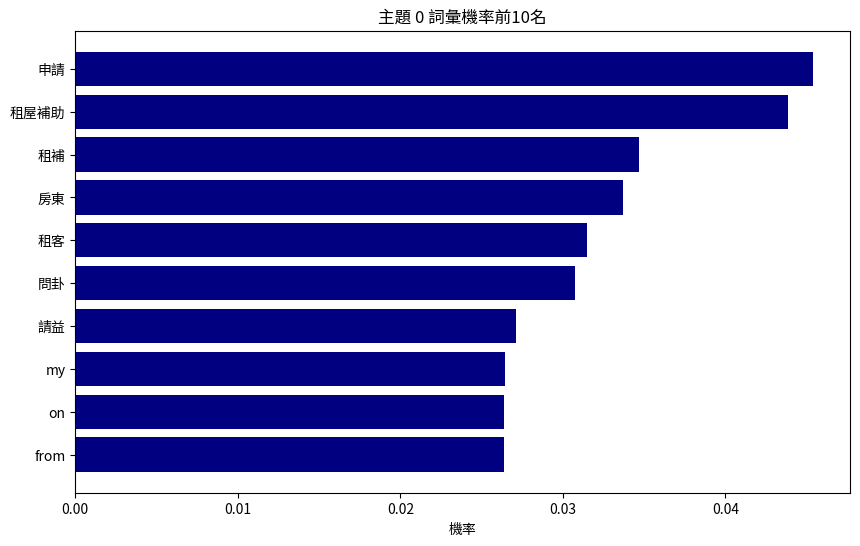

In [ ]:
# 視覺化顯示主題-詞彙分佈
topic_n = 0 # 選擇想觀察的主題編號 (例如：看是否抽出「法律究責」相關字詞)
data = zh_topic_model.get_topic(topic_n)

# 轉換為DataFrame
df_plot = pd.DataFrame(data, columns=['word', 'prob'])
df_plot = df_plot[df_plot['word'] != ' ']

# 根據prob排序並選出前10名
top_10 = df_plot.sort_values('prob', ascending=False).head(10)

# 設定中文字體以避免圖表顯示亂碼 (Windows 預設用微軟正黑體)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False
# 畫出長條圖
plt.figure(figsize=(10,6))
plt.barh(top_10['word'], top_10['prob'], color='navy')
plt.xlabel('機率')
plt.title(f'主題 {topic_n} 詞彙機率前10名')
plt.gca().invert_yaxis()
plt.show()

## 觀察與總結：藏在 19 個主題背後的租屋現場

透過這幾次 BERTopic 的建模實驗，我們不只是完成了一次資料分群，更是側寫了當前台灣租屋族的集體焦慮。從這 19 個主題的消長中，我們可以讀出幾層隱藏在數據底下的社會情緒：

**首先，政策的「善意」正與「市場慣性」激烈摩擦。**  
雖然 Topic 0 和 Topic 1 顯示出大眾對加碼補貼與申請細節有實質需求，但隨即而來的 Topic 7 與 Topic 10 卻揭露了現實的殘酷：當政府把錢發到租客手上時，租客感受到的並非單純的減壓，而是「房東隨即漲租」的壓力，以及「黑市看得到吃不到」的深層無力感。這種從利益分配（拿補助）快速轉化為衝突（對立房東）的現象，是數據中情緒張力最強的部分。

**其次，居住正義在社群討論中已徹底「政治化」。**  
我們在 Topic 17 與 18 看到大量關於賴清德、蔡英文政見達成率的辯論。這反映出租屋補助在 PTT 上早已不是單純的民生福利，而是網友用來檢驗執政者誠信、進行跨黨派攻防的火力來源。當居住問題被放進政治過濾鏡，政策的實質效果往往會被政治標籤所稀釋，這也解釋了為何相關主題中常帶有諷刺或質疑的語氣。

**再者，大環境的生存焦慮是揮之不去的背景音。**  
Topic 4 與 Topic 5 提到 CPI 指數與成本轉嫁，這部分的討論雖然相對冷靜，卻最顯無奈。它指出了租金補貼其實是在跟「通膨」賽跑；當房價與物價持續走揚，補助帶來的微小紅利很快就被大環境的漲幅抵消。這種「治標不治本」的群體共識，也成了政策難以獲得一致好評的主因。

**最後的觀察：**  
這份輿論地圖告訴我們，租屋補助政策觸動的不只是錢包，更是台灣租賃市場長年不透明的痛點。補助申請行為本身，意外成為了一種「實名制檢驗」，逼得原本在水面下的稅務爭議（Topic 16）不得不浮上檯面。這對政府來說，不僅僅是發錢的行政任務，更是一場關於如何重建租客信任、導正市場秩序的長期對話。

### 10.5 用模型進行主題標籤的調整：KeyBERT

此段改寫自 week12_bert.ipynb 第 5.4 節，將 BERTopic 的各元件替換為支援中文的版本：

- **Embedding model**：使用 `google-bert/bert-base-chinese` 將中文句子轉換為向量
- **Tokenizer**：使用 `jieba` 進行中文斷詞，取代預設的英文 tokenizer
- **Representation**：使用 `KeyBERTInspired` 方法從每個主題中抽取最具代表性的中文關鍵詞

此外，預先計算 embeddings 可以加快後續重複執行的速度。

In [ ]:
# !pip install jieba  # 若尚未安裝，取消此行註解執行

import jieba
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from hdbscan import HDBSCAN
from bertopic.representation import KeyBERTInspired

# 準備中文文件
docs_series = sentence_table['text'].dropna().astype(str).str.strip()
docs = docs_series[docs_series != ''].tolist()

# 定義中文停用詞（結合本 notebook 資料前處理已使用的停用詞集）
zh_stopwords = [
    '的', '是', '不', '有', '我', '就', '也', '一', '在', '了', '要', '個',
    '這', '都', '會', '你', '說', '人', '但', '還', '他', '沒', '跟', '能',
    '讓', '很', '被', '來', '可', '到', '與', '去', '為', '再', '或', '及',
    '對', '上', '想', '等', '後', '好', '才', '那', '多', '年', '月', '元',
    '一個', '一些', '一下', '不是', '可以', '因為', '所以', '如果', '但是',
    '就是', '沒有', '自己', '覺得', '真的', '這個', '那個', '還是', '可能',
    '現在', '大家', '很多', '有人', '什麼', '怎麼', '為什麼', '是不是',
    '有沒有', '不要', '應該', '新聞', '問卦', '閒聊', '請益', '問題', '討論',
    '心得', '情報', '完整', '標題', '內文', '備註', '媒體', '來源', '記者',
    '署名', '連結', '作者', '看板', '時間', '文章', '引述',
    '表示', '指出', '認為', '直言', '呼籲', '強調', '報導', '發布', '今日',
    '目前', '今年', '去年', '近期', '相關', '部分', '其中', '以及', '包括',
    '透過', '進行', '使用', '需要', '成為', '持續', '提供', '取得',
    '房東', '租客', '租屋',
]

# 定義中文分詞函數（使用 jieba）
def tokenize_zh(text):
    words = jieba.lcut(text)
    return words

# 設定中文 embedding model（bert-base-chinese 適用繁體中文）
bert_sentence_model = SentenceTransformer('google-bert/bert-base-chinese')

# 預先計算文件的向量表示（可加快後續重複實驗速度）
print(f'正在計算 {len(docs)} 篇文件的 embeddings...')
embeddings = bert_sentence_model.encode(docs, show_progress_bar=True)

# 建立使用 jieba 分詞的 CountVectorizer
jieba_vectorizer = CountVectorizer(
    tokenizer=tokenize_zh,
    stop_words=zh_stopwords,
    analyzer='word',
    token_pattern=None,
    min_df=2,
)

# 設定 KeyBERT representation model
representation_model = {'KeyBERT': KeyBERTInspired()}

# 建立 BERTopic 模型（使用中文 embedding + jieba 分詞）
topic_model_repr = BERTopic(
    embedding_model=bert_sentence_model,
    vectorizer_model=jieba_vectorizer,
    hdbscan_model=HDBSCAN(min_cluster_size=10),
    representation_model=representation_model,
    top_n_words=20,
    verbose=True,
)

# 訓練模型（傳入預先計算好的 embeddings 節省時間）
topics_repr, probs_repr = topic_model_repr.fit_transform(docs, embeddings)
topic_info_repr = topic_model_repr.get_topic_info()
display_cols = [c for c in ['Topic', 'Count', 'Name', 'Representation', 'KeyBERT'] if c in topic_info_repr.columns]
topic_info_repr[display_cols].head(20)

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Topic</th>
      <th>Count</th>
      <th>Name</th>
      <th>Representation</th>
      <th>KeyBERT</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>-1</td>
      <td>3665</td>
      <td>-1_，_ _、_租金</td>
      <td>[，,  , 、, 租金, 「, 」, 補貼, 申請, 補助, 房客, 政府, 住宅, 社宅, 政策, 於, ：, ., 租, 萬, 嗎]</td>
      <td>[內政部, 房子, 出租人, 報稅, 補助, 房客, 社宅, 希望, 未來, 房稅]</td>
    </tr>
    <tr>
      <th>1</th>
      <td>0</td>
      <td>209</td>
      <td>0_家庭_倍_子女_加碼</td>
      <td>[家庭, 倍, 子女, 加碼, 歲, 青年, 未成年, 育有, 每月, 新婚, 至, 每人, 金額, 單身, 補貼, 育兒, 寬, 1, 婚育, 平均]</td>
      <td>[1.4, 1.2, 措施, 3.5, 1.8, 及育兒, 減輕, 標準, 針對, 戶數]</td>
    </tr>
    <tr>
      <th>2</th>
      <td>1</td>
      <td>188</td>
      <td>1_補助_申請_嗎_請問</td>
      <td>[補助, 申請, 嗎, 請問, 請, 各位, 小弟, 出租, 合約, 男友, 自用, 簽約, 母親, 是否, 最近, 想問, 申請過, 仲介, 房客, 知道]</td>
      <td>[房子, 承租人, 申請過, 請問, 出租人, 打算, 謝謝, 租補, 想問, 報稅]</td>
    </tr>
    <tr>
      <th>3</th>
      <td>2</td>
      <td>182</td>
      <td>2_re_：_族_發不出</td>
      <td>[re, ：, 族, 發不出, 晚申, 補貼, 全台, 快, 變革, 何解, 搶, 租金, 擋, 法禁, 哭, 不到, 變小, 重大, 修, 租補]</td>
      <td>[房東漲, 房東降, 修租賃, 租補, 發不出, 房東共體, 輩租, 報稅會, 億加碼, 高房價]</td>
    </tr>
    <tr>
      <th>4</th>
      <td>3</td>
      <td>123</td>
      <td>3_台北_即時_日報_：</td>
      <td>[台北, 即時, 日報, ：, 經濟, 2025, 聯合報, 補貼, 租金, 2026, 扣除,  , 300, 加碼, 11, 2023, 擴大, 胡...</td>
      <td>[立法院, 內政部, 綜所稅, 聯合報, 行政院, 2026, 中央社, 報稅, 2024, 大亮點]</td>
    </tr>
    <tr>
      <th>5</th>
      <td>4</td>
      <td>117</td>
      <td>4_指數_新高_年增率_房租</td>
      <td>[指數, 新高, 年增率, 房租, ％, 總處, 2%, 顯示, 主計, 漲幅, 最新, 連續, 漲勢, 漲, 根據, 物價, 統計, 創, cpi, 年增]</td>
      <td>[去年同期, 年增率, 消費者, 維修費, 類指數, 指數連, 指數, 仍然, 已連續, 專家]</td>
    </tr>
    <tr>
      <th>6</th>
      <td>5</td>
      <td>107</td>
      <td>5_因素_房價_走揚_成本</td>
      <td>[因素, 房價, 走揚, 成本, 曾敬德, 租金, 漲勢, 上漲, 市場, 帶動, 不動產, 上揚, 企研室, 膨, 經理, 信義, 趨勢, 近年, 總...</td>
      <td>[成本增加, 居高不下, 導致民眾, 專家, 企研室, 研究室, 央行, 指數, 2.0, 持有]</td>
    </tr>
    <tr>
      <th>7</th>
      <td>6</td>
      <td>90</td>
      <td>6_居住_多元_社會_住宅</td>
      <td>[居住, 多元, 社會, 住宅, 興辦, 需求, 中心, 穩健, 推動, 開發, 國, 家住, 落實, 回應, 目標, 方式, 更新, 分回, 、, 國土署]</td>
      <td>[公有土地, 內政部, 並透過, 將持續, 跨部會, 空餘屋, 穩健, 土地, 國土署, 居所]</td>
    </tr>
    <tr>
      <th>8</th>
      <td>7</td>
      <td>77</td>
      <td>7_嗎_re_補助_房東會</td>
      <td>[嗎, re, 補助, 房東會, 降, 拿掉, 補貼, 是給, 關於, 級, 詐騙, 低薪, 失敗, 仔, 房租, 稅級, 申請, 30000, 一種,...</td>
      <td>[報租補, 房東會, 租補, 有租補, 林先生, 大台北, 補助, 稅嗎, 回收, ingimage]</td>
    </tr>
    <tr>
      <th>9</th>
      <td>8</td>
      <td>64</td>
      <td>8_真正_張金鶚_黑市_弱勢</td>
      <td>[真正, 張金鶚, 黑市, 弱勢, 反對, 關鍵, 錢, 過度, 好事, 撒, 解決, 一件, 關心, 政府, 「, 把, 刀口, ，, 」, 相對]</td>
      <td>[這顯然, 給弱勢, 房子, 勢者, 張金鶚, 房東則, 講房價, 多少, 補助給, 回收]</td>
    </tr>
    <tr>
      <th>10</th>
      <td>9</td>
      <td>64</td>
      <td>9_戶_萬_興辦_萬戶</td>
      <td>[戶, 萬, 興辦, 萬戶, ,, 12, 直接, 興建, 已, 開工, 截至, 合計, 達, 全國, 月底, 累計, 建中, 8, 社會, 住宅]</td>
      <td>[規畫, 萬餘戶, 4.6, 行政院, 中央社, 去年底, 2024, 國土署, 達成率, 目標]</td>
    </tr>
    <tr>
      <th>11</th>
      <td>10</td>
      <td>63</td>
      <td>10_不到_」_補貼_批評</td>
      <td>[不到, 」, 補貼, 批評, 「, 黑市, 戶籍, 現象, 曾, 李同榮, 300, 卻, 無法, 族, 民團, 租金, 專家, 廣大, 政策, 巢運]</td>
      <td>[陷入困境, 內政部, 從租賃, 立委, 專家, 違建加, 深入, 應正視, 戶籍, 遷入]</td>
    </tr>
    <tr>
      <th>12</th>
      <td>11</td>
      <td>62</td>
      <td>11_推_23_02_04</td>
      <td>[推, 23, 02, 04, 09, 06, 03, 07, 11, 20, 17, 00, 22, kusomanfcu, 21,  , 29, 3...</td>
      <td>[s26492755, ..., 加價租, kusomanfcu, 當政績, 房客, 漲租, 抑制, 再來, 地板]</td>
    </tr>
    <tr>
      <th>13</th>
      <td>12</td>
      <td>61</td>
      <td>12_戶_安居_仁武_基地</td>
      <td>[戶, 安居, 仁武, 基地, 預計, 廣慈, 中心, 層, 位, 工程, 寮, 鳳翔, 、, 宜居, 共, 規畫, 完工, 站, 區, 分鐘]</td>
      <td>[信義區, 岡山大鵬, 宅基地, 重劃區, 規畫, 楊明峰, 博愛園, 完工, 工程, 機能]</td>
    </tr>
    <tr>
      <th>14</th>
      <td>13</td>
      <td>59</td>
      <td>13_地價稅_每屋_1.5_工業</td>
      <td>[地價稅, 每屋, 1.5, 工業, 房屋, 享有, 優惠, 公益, 萬元免, 每月, 出租人, 稅額, 優惠稅, 必要, 自用, 稅率, 地, 所得,...</td>
      <td>[優惠稅率, 稅計算, 土地增值, 稅減免, 地價稅, 房東稅, 稅額度, 營建署, 單一輕稅, 2.5]</td>
    </tr>
    <tr>
      <th>15</th>
      <td>14</td>
      <td>53</td>
      <td>14_扣除_額_支出_列舉</td>
      <td>[扣除, 額, 支出, 列舉, 標準, 特別, 萬元, 所得, 抵稅, 申報, 改為, 排富, 額度, 股利, 採, 稅額, 租金, 基本, 十八, 分開]</td>
      <td>[綜所稅, 財政部, 費用, 使用率, 計算, 從列舉, 報稅, 額度, 標準, 稅損]</td>
    </tr>
    <tr>
      <th>16</th>
      <td>15</td>
      <td>48</td>
      <td>15_炒地皮_全網_成貪婪_糖衣</td>
      <td>[炒地皮, 全網, 成貪婪, 糖衣, 青安, 毒藥, 炸鍋, 痛批, reference, 房東漲, 邱顯智, 百姓, 蔡家, 自肥, 理由, 房貸, ...</td>
      <td>[房東漲, 好好笑, 抬價, 東資料, 繳房, 炒地皮, 蔡家, 炒地, 邱顯智, 成貪婪]</td>
    </tr>
    <tr>
      <th>17</th>
      <td>16</td>
      <td>47</td>
      <td>16_證明_檢舉_國稅局_漏報</td>
      <td>[證明, 檢舉, 國稅局, 漏報, 轉帳, 稽, 影本, 物品, 文件, 財產, 徵機關, 紀錄, 漏稅, 收據, 捐稽, 契約, 處罰, 彈劾, 之,...</td>
      <td>[及費用, 契約書, 依規定, 稅捐稽, 補助費, 徵機關, 財政部, 國稅局, 應申報, 規定]</td>
    </tr>
    <tr>
      <th>18</th>
      <td>17</td>
      <td>47</td>
      <td>17_賴清德_社宅_上任_政見</td>
      <td>[賴清德, 社宅, 上任, 政見, 卻, 政策, 基層, 不蓋, 承諾, 傳出, 力量, 時代, 清德, 好不容易, 跳票, 不積極, 如今, 理念, ...</td>
      <td>[好不容易, 賴總統, 賴清德, 正義這條, 沒人敢, 近來, 侯友宜, 社宅量, 合理化, 土地]</td>
    </tr>
    <tr>
      <th>19</th>
      <td>18</td>
      <td>41</td>
      <td>18_萬戶_社宅_8_20</td>
      <td>[萬戶, 社宅, 8, 20, 達標, 蓋, 蔡, 進度, 泛, 絕對, ：, 台灣, 國家, 辛苦, 興建, 英文, 公宅, 年底, 開始, 英明]</td>
      <td>[台北市, 內政部, 付不出, 停滯性, 目標, 花敬群, 發錢給, 涵蓋率, 興建量, 稍微]</td>
    </tr>
  </tbody>
</table>
</div>

In [ ]:
custom_labels = {}
for topic_id in topic_info_repr["Topic"]:
    if topic_id == -1:
        continue
    row = topic_info_repr.loc[topic_info_repr["Topic"] == topic_id].iloc[0]
    terms = row.get("KeyBERT", row.get("Representation", []))
    if isinstance(terms, str):
        term_list = [t.strip() for t in terms.split(",") if t.strip()]
    elif isinstance(terms, list):
        term_list = [str(t).strip() for t in terms if str(t).strip()]
    else:
        term_list = []
    label_text = " / ".join(term_list[:3]) if term_list else f"Topic {topic_id}"
    custom_labels[topic_id] = f"T{topic_id}: {label_text}"

topic_model_repr.set_topic_labels(custom_labels)
print("Custom topic label mappings (first 10):")
print(dict(list(custom_labels.items())[:10]))

Custom topic label mappings (first 10):
{0: 'T0: 1.4 / 1.2 / 措施', 1: 'T1: 房子 / 承租人 / 申請過', 2: 'T2: 房東漲 / 房東降 / 修租賃', 3: 'T3: 立法院 / 內政部 / 綜所稅', 4: 'T4: 去年同期 / 年增率 / 消費者', 5: 'T5: 成本增加 / 居高不下 / 導致民眾', 6: 'T6: 公有土地 / 內政部 / 並透過', 7: 'T7: 報租補 / 房東會 / 租補', 8: 'T8: 這顯然 / 給弱勢 / 房子', 9: 'T9: 規畫 / 萬餘戶 / 4.6'}

模型共識別出 19 個主題（Topic 0–18），加上 1 個雜訊類別（Topic -1）。其中 Topic -1 包含 3,665 筆句子，占比約
  47%，這些是與任何主題相似度不足的句子，屬於 BERTopic 中 HDBSCAN
  分群的正常現象，在中文政策討論語料中尤其常見，因為許多句子語意模糊或缺乏明確主題詞。

  以下將 19 個主題依內容性質分為五類進行說明：

  ---
  第一類：補助制度與申請資訊（Topic 0、1、13）

  Topic 0（209 筆）：核心詞為「家庭、倍、子女、加碼、青年、新婚、育兒」，內容集中在租金補貼的加碼條件，如育有未成年子女、新婚家庭、青年等群
  體可獲得額外補貼倍數，反映民眾對補貼金額計算與資格條件的關注。

  Topic 1（188 筆）：核心詞為「補助、申請、嗎、請問、合約、出租、自用」，為典型的 PTT
  提問討論串，民眾互相詢問申請流程、合約要求、出租人是否需要配合等實務問題，KeyBERT
  關鍵詞「承租人、出租人、租補、謝謝」也印證了這是以民眾視角為主的申請諮詢討論。

  Topic 13（59 筆）：核心詞為「地價稅、每屋、優惠、出租人、稅率」，聚焦於房東參與租補計畫可獲得的稅務優惠，如優惠稅率、稅額減免，這是政府吸
  引房東加入合法出租市場的配套誘因機制。

  ---
  第二類：政策批評與效果爭議（Topic 7、8、10、15）

  Topic 7（77 筆）：核心詞為「房東會、降、拿掉、詐騙、低薪、稅級」，反映民眾對補貼是否真正惠及租客的懷疑——擔心房東知道租客有補助後直接漲租
  、「補貼等於轉移給房東」的討論邏輯在此類中頻繁出現。

  Topic 8（64 筆）：KeyBERT 關鍵詞出現「張金鶚」（知名房地產學者），Representation 包含「黑市、弱勢、反對、撒錢、刀口」，顯示此主題為學者與
  輿論對租補政策的批判性討論，核心爭點為：補助未精準到達真正弱勢族群，反而助長黑市租屋。

  Topic 10（63 筆）：核心詞包含「不到、批評、黑市、戶籍、巢運、李同榮、民團」，為民間團體與立委對政策缺失的倡議聲浪，提及戶籍問題（租客無法
  遷入）、黑市租屋難申請補助等結構性困境。

  Topic 15（48 筆）：核心詞為「炒地皮、貪婪、糖衣、毒藥、蔡家、邱顯智、青安」，屬於政治性批評，將租補政策與青安貸款政策連結，認為相關政策變
  相助長投機炒房，是 PTT 政治化討論的典型語境。

  ---
  第三類：住宅市場數據與總體觀察（Topic 4、5）

  Topic 4（117 筆）：核心詞為「指數、新高、年增率、CPI、主計、漲幅」，來源應為主計總處或媒體引用的統計數據，呈現近年房租 CPI
  持續創新高的現象，KeyBERT 詞「消費者物價指數」也直接點出主題。

  Topic 5（107 筆）：核心詞為「因素、房價、走揚、成本、信義、曾敬德、企研室」，屬於房仲業者或分析師對房租上漲原因的解釋，認為房價上揚帶動成
  本轉嫁，是租金漲勢的根本推力。

  ---
  第四類：社會住宅興辦與政治承諾（Topic 6、9、12、17、18）

  Topic 6（90
  筆）：核心詞為「居住、多元、社會住宅、興辦、國土署、推動」，語氣較為官方，屬於政策宣傳或新聞稿語境，強調政府多元管道推動居住正義。

  Topic 9（64 筆）與 Topic 12（61
  筆）：前者聚焦社宅戶數進度（開工、累計、達標等量化指標），後者則出現仁武、廣慈、鳳翔等具體基地地名，代表媒體對個別社宅建案的進度報導。

  Topic 17（47 筆）與 Topic 18（41 筆）：兩者皆與政治人物的社宅承諾相關——Topic 17 批評賴清德上任後社宅政見跳票；Topic 18 則圍繞蔡英文任內 8
   萬戶、20 萬戶等社宅目標是否達成，是 PTT 上常見的跨黨派施政比較討論。

  ---
  第五類：稅務申報與執法（Topic 3、14、16）

  Topic 3（123 筆）：KeyBERT 出現「聯合報、中央社、行政院、2026」等，為新聞媒體報導語境，內容多為租金補貼政策的最新進展與官方說明。

  Topic 14（53
  筆）：核心詞為「扣除、列舉、標準、所得、綜所稅、抵稅」，聚焦報稅時租金支出的列舉扣除額，反映民眾對如何在綜所稅中申報租屋費用的討論。

  Topic 16（47 筆）：核心詞為「檢舉、國稅局、漏報、稽、稅捐稽徵機關」，屬於租屋逃稅檢舉與稅務執法討論，與租補政策連動——因為申請租補等同實名
  化，部分房東因此拒絕配合，進一步引發稅務稽查議題。

  ---
  雜訊主題

  Topic 2（182 筆）：Representation 中出現「re、：、族」等 PTT 推文格式詞，KeyBERT 詞「房東漲、修租賃、億加碼」雖有意義，但整體混雜了 PTT
  引用格式與政策討論，主題純度較低。

  Topic 11（62 筆）：Representation 大量出現時間戳記數字（02、04、09 等）與帳號 ID（kusomanfcu），屬於資料前處理未完全濾除的 PTT
  推文時間軸格式，為雜訊主題，分析時可忽略。

  ---
  小結

  從 19 個主題可以觀察到，PTT 租屋補助政策討論呈現出三個核心軸線：

  1. 申請實務：民眾關心如何申請、合約要求、加碼資格與稅務扣除。
  2. 政策效果爭議：補貼是否轉移給房東、是否惠及弱勢、社宅承諾是否兌現，是最具情緒張力的討論主軸。
  3. 總體經濟環境：CPI 房租漲勢與房價成本轉嫁，為政策討論提供了背景脈絡。

  Topic 11 建議在後續分析中排除，Topic 2 的結果需搭配人工判讀，其餘主題整體具有較高的語意一致性，可用於進一步的時間序列分析或看板間比較。